In [1]:
import os
from collections import defaultdict
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D
from matplotlib.lines import Line2D

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import itertools

In [2]:
os.chdir('..')
from RM_interpretation.benchmarking.dataset import get_evaluation_benchmak

/home/eshaant/Research_project/RM-interpretation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
NORMALISED_DATASET_NAME={
    'rm-bench':"RM Bench",
    'reward_bench':'Reward Bench',
    'reward_bench2':"Reward Bench 2",
}

In [4]:
SEEDS=[0,247,932]
MODEL_NAMES=[
            # 'olmo-2-1b',
            #  'pythia-1b',
            #  'pythia-410m',
            #  'pythia-160m',
            #  'pythia-70m',
            #  'pythia-1.4b',
            #  'pythia-2.8b',
             'smollm2-1.7b',
             'smollm2-135m',
             'smollm2-360m',
            'gpt2-small',
            'gpt2-medium',
            'gpt2-large',
             ]
RM_DATASET_TYPE=[
    'helpful','harmless',
    'helpful-harmless'
    ]
BENCH_DATASETS=['rm-bench','reward_bench','reward_bench2',
                # 'rmb_bench'
                ]
NORMALISED_SUB_TYPE={
    'chat':"Chat",
    'code':"Code",
    'math':"Math",
    'safety-refuse':"Safety Refuse",
    'safety-response':'Safety Response',
    'chat hard':"Chat (Hard)",
    'safety':"Safety",
    'reasoning':"Reasoning",
    'alpacaeval-easy':'Alpaca Eval (Easy)',
    'alpacaeval-hard':'Alpaca Eval (Hard)',
    'alpacaeval-length':'Alpaca Eval (Length)',
    'mt-bench-easy':'MT Bench (Easy)',
    'mt-bench-med':'MT Bench (Med)',
    'mt-bench-hard':'MT Bench (Hard)',
    'llmbar-natural':'LLM Bar (Natural)',
    'llmbar-adver-neighbor':'LLM Bar (Adver Neighbor)',
    'llmbar-adver-GPTInst':'LLM Bar (Adver GPTInst)',
    'llmbar-adver-GPTOut':'LLM Bar (Adver GPTOut)',
    'llmbar-adver-manual':'LLM Bar (Adver Manual)',
    'refusals-dangerous':'Refusals Dangerous',
    'refusals-offensive':'Refusals Offensive',
    'xstest-should-respond':'XStest Should Respond',
   'xstest-should-refuse':'XStest Should Refuse',
   'donotanswer':'Do Not Answer',
   'math-prm':'Math PRM',
   'Ties':'Ties',
    'hep-python':'Hep-Python',
    'hep-go':'Hep-GO',
    'hep-cpp':'Hep-CPP',
    'hep-js':'Hep-JS',
    'hep-rust':'Hep-Rust',
    'hep-java':'Hep-Java',
    'Code':'Code',
    'Factuality':'Factuality',
    'Precise IF':'Precise IF',
   'Math':'Math',
   'Safety':'Safety',
   'Focus':'Focus'
}
SUB_TASK_2_AVOIDE=['Code','Hep-Java','Hep-Rust','Hep-JS','Hep-CPP','Hep-GO','Hep-Python','Ties']
SUB_TASK_2_AVOIDE=[x.lower() for x in SUB_TASK_2_AVOIDE]
SUB_TASK_TYPE={
    'Helpful':['Chat','Math','Alpaca Eval (Easy)',
        'Alpaca Eval (Hard)',     'Alpaca Eval (Length)',
        'MT Bench (Easy)',           'MT Bench (Med)',
        'MT Bench (Hard)',        'LLM Bar (Natural)',
        'LLM Bar (Adver Neighbor)',  'LLM Bar (Adver GPTInst)',
        'LLM Bar (Adver GPTOut)',   'LLM Bar (Adver Manual)',
        'Math PRM','Factuality','Precise IF','Focus'],
    'Harmless':[
        'Safety Refuse','Safety Response',
        'Refusals Dangerous',       'Refusals Offensive',
        'XStest Should Respond',     'XStest Should Refuse',
        'Do Not Answer','Safety'
    ]
}
TYPE_SUB_TASK={v:k for k,vs in SUB_TASK_TYPE.items() for v in vs}
SCORE_TYPE=['change',
            'absolute',
            # 'prob'
            ]
ABALATION_TYPE=[
                        'random_activations',
                        'top_activations',
                       'top_activations_absolute'
                       ]
ABALATION_TYPE1=[
                        'top_activations',
                       'top_activations_absolute'
                       ]
ABALATION_TYPE2=[
    'only_top_helpful_activations_absolute',
    'only_top_harmless_activations_absolute',
    'both_top_helpful_harmless_activations_absolute'
]


In [5]:
sns.set_context(
    "talk",
    rc={
        "axes.titlesize": 14,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "legend.title_fontsize": 14,
    }
)

In [6]:
def radar_factory(num_vars, frame='circle'):
    """Create a radar chart with `num_vars` axes.

    This function creates a RadarAxes projection and registers it.

    Parameters
    ----------
    num_vars : int
        Number of variables for radar chart.
    frame : {'circle' | 'polygon'}
        Shape of frame surrounding axes.

    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)
    
    class RadarTransform(PolarAxes.PolarTransform):
        def transform_path_non_affine(self, path):
            # Paths with non-unit interpolation steps correspond to gridlines,
            # in which case we force interpolation (to defeat PolarTransform's
            # autoconversion to circular arcs).
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):

        name = 'radar'
        
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location('N')

        # def fill(self, *args, closed=True, **kwargs):
        #     """Override fill so that line is closed by default"""
        #     return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            # FIXME: markers at x[0], y[0] get doubled-up
            if x[0] != x[-1]:
                x = np.concatenate((x, [x[0]]))
                y = np.concatenate((y, [y[0]]))
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                      radius=.5, edgecolor="k")
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

        def draw(self, renderer):
            """ Draw. If frame is polygon, make gridlines polygon-shaped """
            if frame == 'polygon':
                gridlines = self.yaxis.get_gridlines()
                for gl in gridlines:
                    gl.get_path()._interpolation_steps = num_vars
            super().draw(renderer)


        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                spine = Spine(axes=self,
                              spine_type='circle',
                              path=Path.unit_regular_polygon(num_vars))
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)


                return {'polar': spine}
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta
def prepare_radar(labels):
    labels_normalised = [l.replace('-', ' ').capitalize() for l in labels]
    num_vars = len(labels)

    theta = radar_factory(num_vars, frame='polygon')
    theta_closed = np.concatenate([theta, [theta[0]]])

    return labels, labels_normalised, theta_closed


def plot_radar(result_model, labels, rm_types, title, save_path, rgrids):
    labels, labels_normalised, theta_closed = prepare_radar(labels)

    fig, ax = plt.subplots(figsize=(10, 10),
                           subplot_kw=dict(projection='radar'))

    for dataset_type in rm_types:
        data = result_model[dataset_type]
        means = [data[k] for k in labels]
        means_closed = np.concatenate([means, [means[0]]])

        ax.plot(theta_closed, means_closed, linewidth=2, label=dataset_type)

    ax.set_rgrids(rgrids)
    ax.set_varlabels(labels_normalised)
    ax.set_ylim(0, 100)

    plt.legend(loc='lower right', bbox_to_anchor=(1.4, -0.2), ncol=3)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()

In [7]:
def get_top_indices(score_array, p):
    threshold = np.percentile(score_array, 100 - p)
    indices = np.argwhere(score_array >= threshold)

    ablate_map = set()
    for layer, idx in indices:
        ablate_map.add((int(layer),int(idx)))

    return ablate_map

def get_activated_indices(score_array):
    indices = np.argwhere(score_array > 0)

    ablate_map = set()
    for layer, idx in indices:
        ablate_map.add((int(layer),int(idx)))

    return ablate_map



In [8]:
def get_random_accuracy(dataset):
    total_chosen_count=defaultdict(float)
    total_rejected_count=defaultdict(float)
    for i in dataset['chosen2ids']:
        total_chosen_count[i]+=1
    for i in dataset['rejected2ids']:
        total_rejected_count[i]+=1

    ids_subsets=dict(zip(dataset['ids'],dataset['subsub_set']))
    sub_task_random_accs=defaultdict(list)
    for id,subset in ids_subsets.items():
        if subset in NORMALISED_SUB_TYPE:
            subset=NORMALISED_SUB_TYPE[subset]
        sub_task_random_accs[subset].append(total_chosen_count[id]/(total_rejected_count[id]+total_chosen_count[id]))
    random_acc={key:100*sum(value)/len(value) for key,value in sub_task_random_accs.items()}
    return random_acc
random_acc={}
for bench_dataset in BENCH_DATASETS:
    print("Computing random performance for ",bench_dataset)
    random_dict=get_random_accuracy(get_evaluation_benchmak(bench_dataset))
    for key,value in random_dict.items():
        random_acc[key]=value

Computing random performance for  rm-bench
Retriving datasets.
Computing random performance for  reward_bench
Retriving datasets.
Computing random performance for  reward_bench2
Retriving datasets.


In [9]:
# Retriving sub-type information
def get_subsub_set(dataset):
    return dataset['subsub_set']
subsub_set={}
for bench_dataset in BENCH_DATASETS:
    print("Retriving sub-type information",bench_dataset)
    subsub_set[bench_dataset]=get_subsub_set(get_evaluation_benchmak(bench_dataset))

Retriving sub-type information rm-bench
Retriving datasets.
Retriving sub-type information reward_bench
Retriving datasets.
Retriving sub-type information reward_bench2
Retriving datasets.


# Evaluating RM benchmarks

## Computing Plot

In [17]:
import json
df_model_name=[]
df_sub_task=[]
df_dataset_name=[]
df_varence=[]
df_accuracy=[]
df_model_type=[]
for model_name in MODEL_NAMES:
    for rm_dataset_type in RM_DATASET_TYPE:
        for bench_dataset in BENCH_DATASETS:
            accuracy_dictionary={}
            for seed in SEEDS:
                path_name=path_name=f'./save/results/{model_name}_{rm_dataset_type}_{seed}/{bench_dataset}.json'
                with open(path_name, "r") as f:
                    load_dict = json.load(f)
                sub_set=subsub_set[bench_dataset]
                results=load_dict['results']
                indexed_results=defaultdict(list)
                for item,idx in zip(results,sub_set):
                    indexed_results[idx].append(item)
                for key,value in indexed_results.items():
                    accuracy=sum(value)/len(value)*100

                    if key in accuracy_dictionary:
                        accuracy_dictionary[key].append(accuracy)
                    else:
                        accuracy_dictionary[key]=[accuracy]

            for key,value in accuracy_dictionary.items():
                if key.lower() in SUB_TASK_2_AVOIDE:
                    continue
                else:
                    df_model_name.append(model_name)
                    df_sub_task.append(key)
                    df_dataset_name.append(bench_dataset)
                    df_varence.append(float(np.std(value)))
                    df_accuracy.append(float(np.mean(value)))
                    df_model_type.append(rm_dataset_type)


df=pd.DataFrame(
    {
        'model_name':df_model_name,
        'sub_task':df_sub_task,
        'dataset_name':df_dataset_name,
        'varence':df_varence,
        'accuracy':df_accuracy,
        'rm_type':df_model_type
    }
)

In [18]:
df['sub_task']=df['sub_task'].replace(NORMALISED_SUB_TYPE)
df.to_csv('save/results/performance.csv')
result = df.groupby(['rm_type','sub_task'])['accuracy'].mean().unstack().to_dict(orient='index')
result['Random']=random_acc

In [19]:
df.groupby(['model_name','rm_type','sub_task'])['accuracy'].mean().unstack().to_dict(orient='index')

{('gpt2-large', 'harmless'): {'Alpaca Eval (Easy)': 8.0,
  'Alpaca Eval (Hard)': 10.526315789473685,
  'Alpaca Eval (Length)': 34.73684210526316,
  'Chat': 53.48837209302325,
  'Do Not Answer': 86.76470588235294,
  'Factuality': 30.807017543859647,
  'Focus': 45.656565656565654,
  'LLM Bar (Adver GPTInst)': 76.44927536231883,
  'LLM Bar (Adver GPTOut)': 65.95744680851064,
  'LLM Bar (Adver Manual)': 67.39130434782608,
  'LLM Bar (Adver Neighbor)': 75.3731343283582,
  'LLM Bar (Natural)': 45.0,
  'MT Bench (Easy)': 41.666666666666664,
  'MT Bench (Hard)': 52.252252252252255,
  'MT Bench (Med)': 53.333333333333336,
  'Math': 35.87843165611302,
  'Math PRM': 74.27293064876956,
  'Precise IF': 25.208333333333332,
  'Refusals Dangerous': 100.0,
  'Refusals Offensive': 100.0,
  'Safety': 66.8888888888889,
  'Safety Refuse': 99.2566510172144,
  'Safety Response': 8.634111818825195,
  'XStest Should Refuse': 99.35064935064935,
  'XStest Should Respond': 3.1999999999999997},
 ('gpt2-large', 'he

In [20]:
df.groupby(['model_name','rm_type','sub_task'])['varence'].mean().unstack().to_dict(orient='index')

{('gpt2-large', 'harmless'): {'Alpaca Eval (Easy)': 1.4142135623730951,
  'Alpaca Eval (Hard)': 1.488645855129574,
  'Alpaca Eval (Length)': 4.785326911223109,
  'Chat': 1.383495125254869,
  'Do Not Answer': 1.0398629135096276,
  'Factuality': 0.26257244819466274,
  'Focus': 1.0301049522409653,
  'LLM Bar (Adver GPTInst)': 2.2334833344090503,
  'LLM Bar (Adver GPTOut)': 3.0089650263257317,
  'LLM Bar (Adver Manual)': 3.074377309506728,
  'LLM Bar (Adver Neighbor)': 1.6121245518427472,
  'LLM Bar (Natural)': 3.7416573867739413,
  'MT Bench (Easy)': 4.45435403187374,
  'MT Bench (Hard)': 2.5481325448163865,
  'MT Bench (Med)': 2.3570226039551616,
  'Math': 1.505041450454436,
  'Math PRM': 7.196025701306381,
  'Precise IF': 1.6404183070857954,
  'Refusals Dangerous': 0.0,
  'Refusals Offensive': 0.0,
  'Safety': 1.0102356812582112,
  'Safety Refuse': 0.36281762501938913,
  'Safety Response': 1.0008588551826572,
  'XStest Should Refuse': 0.5301925850180057,
  'XStest Should Respond': 0.979

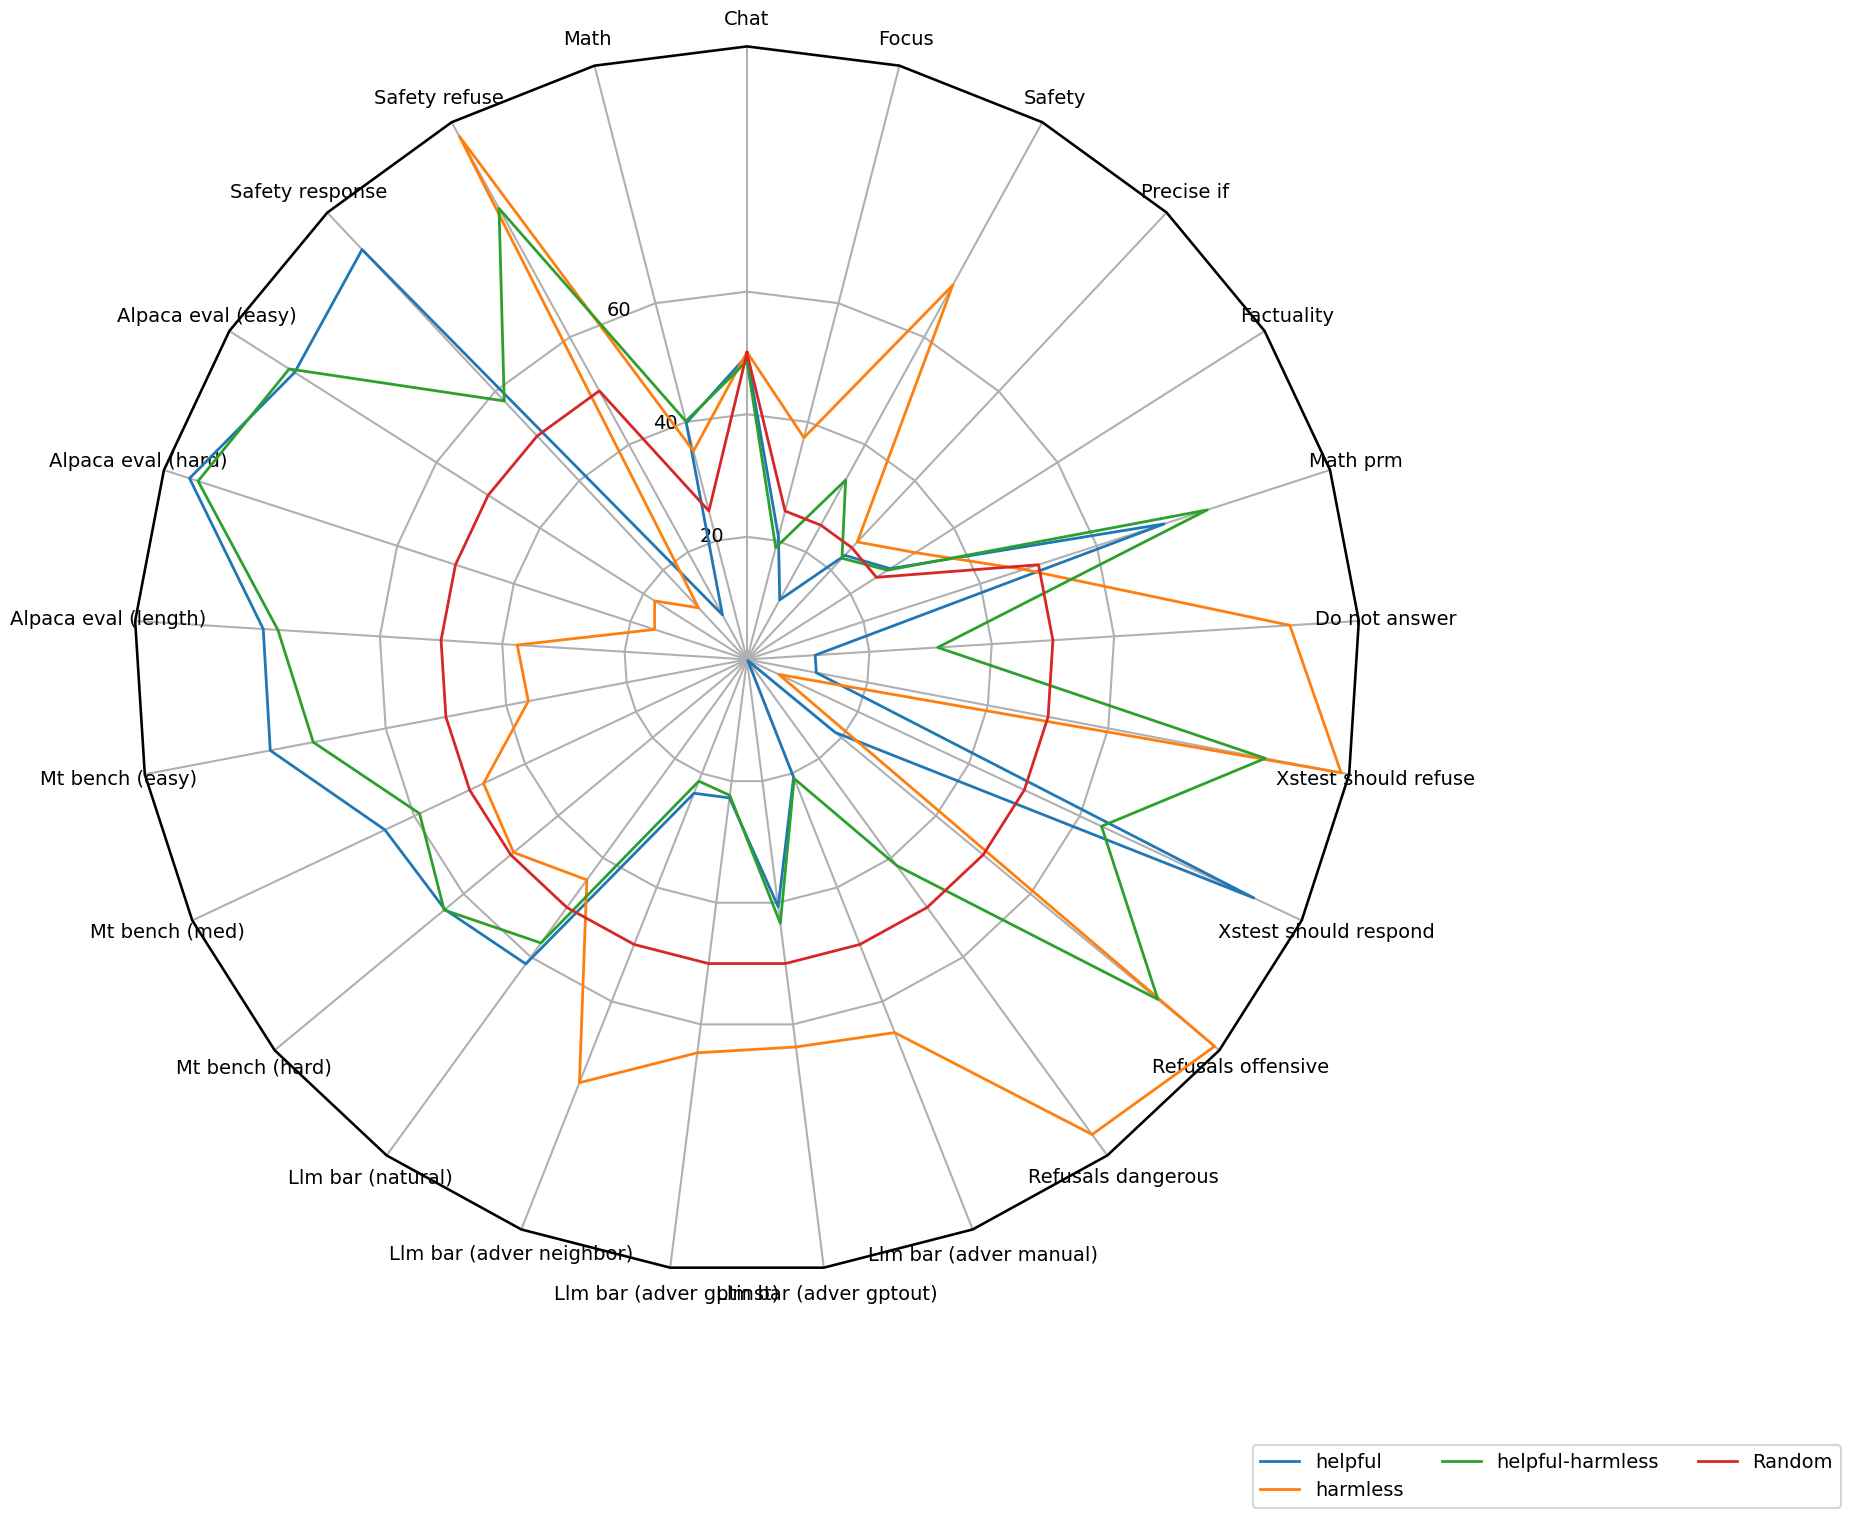

In [21]:
import numpy as np
import matplotlib.pyplot as plt

rm_types = ['helpful', 'harmless', 'helpful-harmless',
            'Random'
            ]


#labels_2_avoide=[]

# Get labels from first dataset
labels=df['sub_task'].unique().tolist()
labels_normalised = [l.replace('-', ' ').capitalize() for l in labels]

num_vars = len(labels)

theta = radar_factory(num_vars, frame='polygon')
theta_closed = np.concatenate([theta, [theta[0]]])

fig, ax = plt.subplots(
    figsize=(20, 20),
    subplot_kw=dict(projection='radar')
)

for dataset_type in rm_types:
    data = result[dataset_type]

    means = [data[k] for k in labels]
    means_closed = np.concatenate([means, [means[0]]])

    ax.set_rgrids([20, 40, 60])
    ax.plot(theta_closed, means_closed, linewidth=2, label=dataset_type)

ax.set_varlabels(labels_normalised)
ax.set_ylim(0, 100)

plt.legend(loc='lower right', bbox_to_anchor=(1.4, -0.2), ncol=3)
plt.tight_layout()
plt.show()

In [22]:
def compute_result_model(df, model_name):
    return (
        df[df['model_name'] == model_name]
        .groupby(['rm_type', 'sub_task'])['accuracy']
        .mean()
        .unstack()
        .to_dict(orient='index')
    )

for model_name in MODEL_NAMES:
    print(model_name)

    result_model = compute_result_model(df, model_name)

    # Helpful
    plot_radar(
        result_model,
        labels=list(SUB_TASK_TYPE['Helpful']),
        rm_types=RM_DATASET_TYPE,
        title='Helpful',
        save_path=f'save/fig/radar_plot_Helpful_{model_name}.svg',
        rgrids=[20, 40, 60]
    )

    # Harmless
    plot_radar(
        result_model,
        labels=list(SUB_TASK_TYPE['Harmless']),
        rm_types=RM_DATASET_TYPE,
        title='Harmless',
        save_path=f'save/fig/radar_plot_Harmless_{model_name}.svg',
        rgrids=[20, 40, 60, 80]
    )
# Helpful
plot_radar(
    result,
    labels=list(SUB_TASK_TYPE['Helpful']),
    rm_types=RM_DATASET_TYPE,
    title='Helpful',
    save_path='save/fig/radar_plot_Helpful.svg',
    rgrids=[20, 40, 60]
)
plot_radar(
    result,
    labels=list(SUB_TASK_TYPE['Harmless']),
    rm_types=RM_DATASET_TYPE,
    title='Harmless',
    save_path='save/fig/radar_plot_Harmless.svg',
    rgrids=[20, 40, 60, 80]
)

smollm2-1.7b
smollm2-135m
smollm2-360m
gpt2-small
gpt2-medium
gpt2-large


## Transferance

In [23]:
df_model_name = []
df_sub_task = []
df_dataset_name = []
df_variance = []
df_transferability = []

for model_name in MODEL_NAMES:
    for bench_dataset in BENCH_DATASETS:

        transferability_dict = defaultdict(list)

        for seed in SEEDS:
            he_path = f'./save/results/{model_name}_helpful_{seed}/{bench_dataset}.json'
            ha_path = f'./save/results/{model_name}_harmless_{seed}/{bench_dataset}.json'
            hh_path = f'./save/results/{model_name}_helpful-harmless_{seed}/{bench_dataset}.json'

            with open(he_path) as f:
                he_results = json.load(f)['results']
            with open(ha_path) as f:
                ha_results = json.load(f)['results']
            with open(hh_path) as f:
                hh_results = json.load(f)['results']

            sub_set = subsub_set[bench_dataset]

            he_idx = defaultdict(list)
            ha_idx = defaultdict(list)
            hh_idx = defaultdict(list)

            for he, ha, hh, idx in zip(he_results, ha_results, hh_results, sub_set):
                he_idx[idx].append(he)
                ha_idx[idx].append(ha)
                hh_idx[idx].append(hh)

            for key in hh_idx.keys():
                intersection = 0
                union = 0

                for i in range(len(hh_idx[key])):

                    # HH correct AND (Helpful OR Harmless correct)
                    if (
                        hh_idx[key][i] == 1 and
                        (he_idx[key][i] == 1 or ha_idx[key][i] == 1)
                    ):
                        intersection += 1

                    # Helpful OR Harmless correct
                    if he_idx[key][i] == 1 or ha_idx[key][i] == 1:
                        union += 1

                transferability = intersection / union if union > 0 else 0.0
                transferability_dict[key].append(transferability)

        for key, values in transferability_dict.items():
            if key.lower() in SUB_TASK_2_AVOIDE:
                continue

            df_model_name.append(model_name)
            df_sub_task.append(key)
            df_dataset_name.append(bench_dataset)
            df_variance.append(float(np.std(values)))
            df_transferability.append(float(np.mean(values)))

df = pd.DataFrame({
    'model_name': df_model_name,
    'sub_task': df_sub_task,
    'dataset_name': df_dataset_name,
    'variance': df_variance,
    'transferance': df_transferability
})

df['sub_task'] = df['sub_task'].replace(NORMALISED_SUB_TYPE)

In [31]:
df_model_name = []
df_sub_task = []
df_dataset_name = []

df_transferability = []
df_variance = []

df_pair_he = []
df_pair_he_var = []

df_pair_ha = []
df_pair_ha_var = []

for model_name in MODEL_NAMES:
    for bench_dataset in BENCH_DATASETS:

        transferability_dict = defaultdict(list)
        pairwise_he_dict = defaultdict(list)
        pairwise_ha_dict = defaultdict(list)

        for seed in SEEDS:
            he_path = f'./save/results/{model_name}_helpful_{seed}/{bench_dataset}.json'
            ha_path = f'./save/results/{model_name}_harmless_{seed}/{bench_dataset}.json'
            hh_path = f'./save/results/{model_name}_helpful-harmless_{seed}/{bench_dataset}.json'

            with open(he_path) as f:
                he_results = json.load(f)['results']
            with open(ha_path) as f:
                ha_results = json.load(f)['results']
            with open(hh_path) as f:
                hh_results = json.load(f)['results']

            sub_set = subsub_set[bench_dataset]

            he_idx = defaultdict(list)
            ha_idx = defaultdict(list)
            hh_idx = defaultdict(list)

            for he, ha, hh, idx in zip(he_results, ha_results, hh_results, sub_set):
                he_idx[idx].append(he)
                ha_idx[idx].append(ha)
                hh_idx[idx].append(hh)

            for key in hh_idx.keys():
                inter_union = 0
                union_union = 0

                inter_he = 0
                union_he = 0

                inter_ha = 0
                union_ha = 0

                for i in range(len(hh_idx[key])):
                    hh = hh_idx[key][i]
                    he = he_idx[key][i]
                    ha = ha_idx[key][i]

                    # --- HH vs (Helpful ∪ Harmless) ---
                    if hh == 1 and (he == 1 or ha == 1):
                        inter_union += 1
                    if he == 1 or ha == 1:
                        union_union += 1

                    # --- HH vs Helpful ---
                    if hh == 1 and he == 1:
                        inter_he += 1
                    if hh == 1 or he == 1:
                        union_he += 1

                    # --- HH vs Harmless ---
                    if hh == 1 and ha == 1:
                        inter_ha += 1
                    if hh == 1 or ha == 1:
                        union_ha += 1

                transferability = inter_union / union_union if union_union > 0 else 0.0
                pairwise_he = inter_he / union_he if union_he > 0 else 0.0
                pairwise_ha = inter_ha / union_ha if union_ha > 0 else 0.0

                transferability_dict[key].append(transferability)
                pairwise_he_dict[key].append(pairwise_he)
                pairwise_ha_dict[key].append(pairwise_ha)

        # Aggregate across seeds
        for key in transferability_dict.keys():
            if key.lower() in SUB_TASK_2_AVOIDE:
                continue

            df_model_name.append(model_name)
            df_sub_task.append(key)
            df_dataset_name.append(bench_dataset)

            df_transferability.append(float(np.mean(transferability_dict[key])))
            df_variance.append(float(np.std(transferability_dict[key])))

            df_pair_he.append(float(np.mean(pairwise_he_dict[key])))
            df_pair_he_var.append(float(np.std(pairwise_he_dict[key])))

            df_pair_ha.append(float(np.mean(pairwise_ha_dict[key])))
            df_pair_ha_var.append(float(np.std(pairwise_ha_dict[key])))

df = pd.DataFrame({
    'model_name': df_model_name,
    'sub_task': df_sub_task,
    'dataset_name': df_dataset_name,

    'transferance': df_transferability,
    'variance': df_variance,

    'hh_he_transfer': df_pair_he,
    'hh_he_variance': df_pair_he_var,

    'hh_ha_transfer': df_pair_ha,
    'hh_ha_variance': df_pair_ha_var,
})

# Normalize sub-task names
df['sub_task'] = df['sub_task'].replace(NORMALISED_SUB_TYPE)

In [35]:
for model in df['model_name'].unique():
    print(model)
    df_model=df[df['model_name']==model]
    print("score")
    print(df_model.groupby(['sub_task'])['transferance'].mean())
    print("varaince")
    print(df_model.groupby(['sub_task'])['variance'].mean())



smollm2-1.7b
score
sub_task
Alpaca Eval (Easy)          0.969247
Alpaca Eval (Hard)          0.982381
Alpaca Eval (Length)        0.867297
Chat                        0.686606
Do Not Answer               0.430504
Factuality                  0.535859
Focus                       0.513901
LLM Bar (Adver GPTInst)     0.357186
LLM Bar (Adver GPTOut)      0.427746
LLM Bar (Adver Manual)      0.383007
LLM Bar (Adver Neighbor)    0.321142
LLM Bar (Natural)           0.760870
MT Bench (Easy)             0.927249
MT Bench (Hard)             0.818729
MT Bench (Med)              0.787180
Math                        0.589051
Math PRM                    0.689815
Precise IF                  0.369457
Refusals Dangerous          0.692492
Refusals Offensive          0.953333
Safety                      0.528926
Safety Refuse               0.938896
Safety Response             0.649398
XStest Should Refuse        0.980519
XStest Should Respond       0.698217
Name: transferance, dtype: float64
varaince
sub

In [40]:
print("variance")
print(df_model.groupby(['sub_task'])['hh_ha_variance'].mean())
    
print("score")
print(df_model.groupby(['sub_task'])['hh_ha_transfer'].mean())

variance
sub_task
Alpaca Eval (Easy)          0.005445
Alpaca Eval (Hard)          0.014145
Alpaca Eval (Length)        0.064272
Chat                        0.015663
Do Not Answer               0.033616
Factuality                  0.016042
Focus                       0.026259
LLM Bar (Adver GPTInst)     0.015906
LLM Bar (Adver GPTOut)      0.020263
LLM Bar (Adver Manual)      0.049495
LLM Bar (Adver Neighbor)    0.016967
LLM Bar (Natural)           0.048174
MT Bench (Easy)             0.090169
MT Bench (Hard)             0.047588
MT Bench (Med)              0.079018
Math                        0.020676
Math PRM                    0.046369
Precise IF                  0.010115
Refusals Dangerous          0.041899
Refusals Offensive          0.094163
Safety                      0.044394
Safety Refuse               0.055702
Safety Response             0.017119
XStest Should Refuse        0.029201
XStest Should Respond       0.008196
Name: hh_ha_variance, dtype: float64
score
sub_task
Alpac

In [41]:
print("variance")
print(df_model.groupby(['sub_task'])['hh_he_variance'].mean())
    
print("score")
print(df_model.groupby(['sub_task'])['hh_he_transfer'].mean())

variance
sub_task
Alpaca Eval (Easy)          0.032290
Alpaca Eval (Hard)          0.036523
Alpaca Eval (Length)        0.094633
Chat                        0.068358
Do Not Answer               0.069677
Factuality                  0.065435
Focus                       0.034890
LLM Bar (Adver GPTInst)     0.097808
LLM Bar (Adver GPTOut)      0.170010
LLM Bar (Adver Manual)      0.183782
LLM Bar (Adver Neighbor)    0.055680
LLM Bar (Natural)           0.056957
MT Bench (Easy)             0.140002
MT Bench (Hard)             0.091461
MT Bench (Med)              0.084541
Math                        0.060681
Math PRM                    0.064925
Precise IF                  0.093595
Refusals Dangerous          0.000000
Refusals Offensive          0.049469
Safety                      0.073537
Safety Refuse               0.020179
Safety Response             0.064711
XStest Should Refuse        0.069170
XStest Should Respond       0.026662
Name: hh_he_variance, dtype: float64
score
sub_task
Alpac

## Scoreing plots

In [124]:
BENCH_DATASETS

['rm-bench', 'reward_bench', 'reward_bench2']

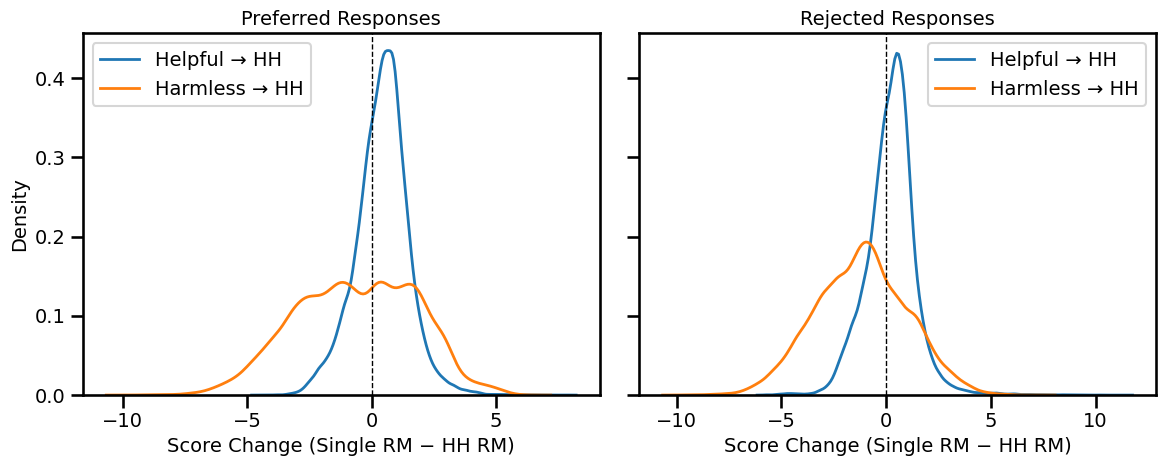

In [10]:
he_pref_score_chage=[]
he_rej_score_chage=[]
ha_pref_score_chage=[]
ha_rej_score_chage=[]

for model_name in MODEL_NAMES:
    for bench_dataset in BENCH_DATASETS:

        score_change_pref = defaultdict(list)
        score_change_rej = defaultdict(list)
        transfer_counts = defaultdict(int)
        total_counts = defaultdict(int)

        for seed in SEEDS:
            he_path = f'./save/results/{model_name}_helpful_{seed}/{bench_dataset}.json'
            ha_path = f'./save/results/{model_name}_harmless_{seed}/{bench_dataset}.json'
            hh_path = f'./save/results/{model_name}_helpful-harmless_{seed}/{bench_dataset}.json'
            with open(he_path) as f:
                he_results = json.load(f)
            with open(ha_path) as f:
                ha_results = json.load(f)
            with open(hh_path) as f:
                hh_results = json.load(f)

            transferability_he=np.array(he_results['results'])+np.array(hh_results['results'])==2
            he_pref_score_chage.extend((np.array(he_results['score_pref'])[:,0]-np.array(hh_results['score_pref'])[:,0])[transferability_he])
            he_rej_score_chage.extend((np.array(he_results['score_pref'])[:,1]-np.array(hh_results['score_pref'])[:,1])[transferability_he])

            transferability_ha=np.array(ha_results['results'])+np.array(hh_results['results'])==2
            ha_pref_score_chage.extend((np.array(ha_results['score_pref'])[:,0]-np.array(hh_results['score_pref'])[:,0])[transferability_ha])
            ha_rej_score_chage.extend((np.array(ha_results['score_pref'])[:,1]-np.array(hh_results['score_pref'])[:,1])[transferability_ha])
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# ---- Preferred responses ----
sns.kdeplot(
    he_pref_score_chage,
    label="Helpful → HH",
    linewidth=2,
    ax=axes[0]
)
sns.kdeplot(
    ha_pref_score_chage,
    label="Harmless → HH",
    linewidth=2,
    ax=axes[0]
)

axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Preferred Responses")
axes[0].set_xlabel("Score Change (Single RM − HH RM)")
axes[0].set_ylabel("Density")
axes[0].legend()

# ---- Rejected responses ----
sns.kdeplot(
    he_rej_score_chage,
    label="Helpful → HH",
    linewidth=2,
    ax=axes[1]
)
sns.kdeplot(
    ha_rej_score_chage
    ,
    label="Harmless → HH",
    linewidth=2,
    ax=axes[1]
)

axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Rejected Responses")
axes[1].set_xlabel("Score Change (Single RM − HH RM)")
axes[1].legend()

plt.tight_layout()
plt.show()


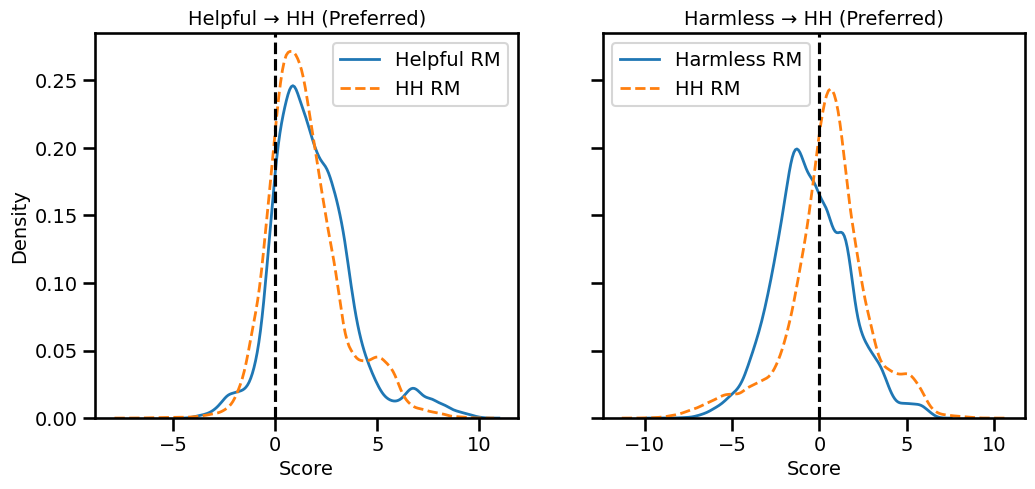

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json

# storage
he_pref, he_rej = [], []
hh_pref_he, hh_rej_he = [], []

ha_pref, ha_rej = [], []
hh_pref_ha, hh_rej_ha = [], []

for model_name in MODEL_NAMES:
    for bench_dataset in BENCH_DATASETS:
        for seed in SEEDS:

            he_path = f'./save/results/{model_name}_helpful_{seed}/{bench_dataset}.json'
            ha_path = f'./save/results/{model_name}_harmless_{seed}/{bench_dataset}.json'
            hh_path = f'./save/results/{model_name}_helpful-harmless_{seed}/{bench_dataset}.json'

            he = json.load(open(he_path))
            ha = json.load(open(ha_path))
            hh = json.load(open(hh_path))

            he_pred = np.array(he["results"])
            ha_pred = np.array(ha["results"])
            hh_pred = np.array(hh["results"])

            he_scores = np.array(he["score_pref"])
            ha_scores = np.array(ha["score_pref"])
            hh_scores = np.array(hh["score_pref"])

            # ---- Helpful → HH ----
            mask_he = (he_pred + hh_pred) == 2

            he_pref.extend(he_scores[mask_he, 0])
            he_rej.extend(he_scores[mask_he, 1])
            hh_pref_he.extend(hh_scores[mask_he, 0])
            hh_rej_he.extend(hh_scores[mask_he, 1])

            # ---- Harmless → HH ----
            mask_ha = (ha_pred + hh_pred) == 2

            ha_pref.extend(ha_scores[mask_ha, 0])
            ha_rej.extend(ha_scores[mask_ha, 1])
            hh_pref_ha.extend(hh_scores[mask_ha, 0])
            hh_rej_ha.extend(hh_scores[mask_ha, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# -------- TOP ROW: PREFERRED --------

# ---- Helpful (Preferred) ----
sns.kdeplot(he_pref+he_rej, label="Helpful RM", linewidth=2, ax=axes[0])
sns.kdeplot(hh_pref_he+hh_rej_he, label="HH RM", linewidth=2, linestyle="--", ax=axes[0])

axes[0].set_title("Helpful → HH (Preferred)")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Density")
axes[0].axvline(0, linestyle="--", color="black")
axes[0].legend()

# ---- Harmless (Preferred) ----
sns.kdeplot(ha_pref+ha_rej, label="Harmless RM", linewidth=2, ax=axes[1])
sns.kdeplot(hh_pref_ha+hh_rej_ha, label="HH RM", linewidth=2, linestyle="--", ax=axes[1])

axes[1].set_title("Harmless → HH (Preferred)")
axes[1].set_xlabel("Score")
axes[1].axvline(0, linestyle="--", color="black")
axes[1].legend()


# # -------- BOTTOM ROW: REJECTED --------

# # ---- Helpful (Rejected) ----
# sns.kdeplot(he_rej, label="Helpful RM", linewidth=2, ax=axes[1, 0])
# sns.kdeplot(hh_rej_he, label="HH RM", linewidth=2, linestyle="--", ax=axes[1, 0])

# axes[1, 0].set_title("Helpful → HH (Rejected)")
# axes[1, 0].set_xlabel("Score")
# axes[1, 0].set_ylabel("Density")
# axes[1, 0].axvline(0, linestyle="--", color="black")
# axes[1, 0].legend()

# # ---- Harmless (Rejected) ----
# sns.kdeplot(ha_rej, label="Harmless RM", linewidth=2, ax=axes[1, 1])
# sns.kdeplot(hh_rej_ha, label="HH RM", linewidth=2, linestyle="--", ax=axes[1, 1])

# axes[1, 1].set_title("Harmless → HH (Rejected)")
# axes[1, 1].set_xlabel("Score")
# axes[1, 1].axvline(0, linestyle="--", color="black")
# axes[1, 1].legend()

plt.savefig('save/fig/scoring_of_transferable.pdf')
plt.show()


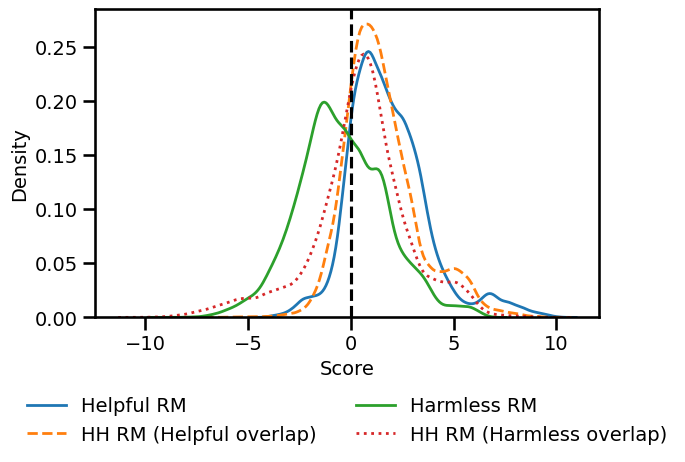

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json

# storage
he_scores_all, hh_scores_he_all = [], []
ha_scores_all, hh_scores_ha_all = [], []

for model_name in MODEL_NAMES:
    for bench_dataset in BENCH_DATASETS:
        for seed in SEEDS:

            he_path = f'./save/results/{model_name}_helpful_{seed}/{bench_dataset}.json'
            ha_path = f'./save/results/{model_name}_harmless_{seed}/{bench_dataset}.json'
            hh_path = f'./save/results/{model_name}_helpful-harmless_{seed}/{bench_dataset}.json'

            he = json.load(open(he_path))
            ha = json.load(open(ha_path))
            hh = json.load(open(hh_path))

            he_pred = np.array(he["results"])
            ha_pred = np.array(ha["results"])
            hh_pred = np.array(hh["results"])

            he_scores = np.array(he["score_pref"])
            ha_scores = np.array(ha["score_pref"])
            hh_scores = np.array(hh["score_pref"])

            # ---- Helpful → HH ----
            mask_he = (he_pred + hh_pred) == 2

            he_scores_all.extend(he_scores[mask_he].flatten())
            hh_scores_he_all.extend(hh_scores[mask_he].flatten())

            # ---- Harmless → HH ----
            mask_ha = (ha_pred + hh_pred) == 2

            ha_scores_all.extend(ha_scores[mask_ha].flatten())
            hh_scores_ha_all.extend(hh_scores[mask_ha].flatten())

# =========================
# Single combined figure
# =========================
plt.figure(figsize=(6.5,4))

# Helpful vs HH
sns.kdeplot(
    he_scores_all,
    label="Helpful RM",
    linewidth=2
)

sns.kdeplot(
    hh_scores_he_all,
    label="HH RM (Helpful overlap)",
    linewidth=2,
    linestyle="--"
)

# Harmless vs HH
sns.kdeplot(
    ha_scores_all,
    label="Harmless RM",
    linewidth=2
)

sns.kdeplot(
    hh_scores_ha_all,
    label="HH RM (Harmless overlap)",
    linewidth=2,
    linestyle=":"
)

plt.axvline(0, linestyle="--", color="black")

plt.xlabel("Score")
plt.ylabel("Density")
# plt.title("Score Distribution of Transferable Samples")
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=2,
    frameon=False
)

# plt.tight_layout()
plt.savefig("save/fig/scoring_of_transferable_combined.pdf",bbox_inches="tight")
plt.show()

In [19]:
def mean(lis):
    return sum(lis)/len(lis)
print(mean(he_pref+he_rej))
print(mean(hh_pref_he+hh_rej_he))

print(mean(ha_pref+ha_rej))
print(mean(hh_pref_ha+hh_rej_ha))

1.8089359720682314
1.48325726272199
-0.4323161525105819
0.4605819587086797


In [17]:
df.to_csv('dnsol.csv')

In [ ]:
RM

In [ ]:
import json
df_model_name=[]
df_sub_task=[]
df_dataset_name=[]
df_score=[]
df_model_type=[]
for model_name in MODEL_NAMES:
    for rm_dataset_type in RM_DATASET_TYPE:
        for bench_dataset in BENCH_DATASETS:
            accuracy_dictionary={}
            for seed in SEEDS:
                path_name=path_name=f'./save/results/{model_name}_{rm_dataset_type}_{seed}/{bench_dataset}.json'
                with open(path_name, "r") as f:
                    load_dict = json.load(f)
                correct=np.array(load_dict['results'])>0
                correct_score=(np.array(load_dict['score_pref'])[:,0]-np.array(load_dict['score_pref'])[:,1])[correct]
                correct_type=np.array(load_dict['sub_set'])[correct]

                df_model_name.extend([model_name]*sum(correct))
                df_sub_task.extend(correct_type)
                df_dataset_name.extend([bench_dataset]*sum(correct))
                df_score.extend(correct_score)
                df_model_type.extend([rm_dataset_type]*sum(correct))


df=pd.DataFrame(
    {
        'model_name':df_model_name,
        'sub_task':df_sub_task,
        'dataset_name':df_dataset_name,
        'score Confidence':df_score,
        'model_type':df_model_type
    }
)

In [16]:
df.head()
sub_task_2_remove=['code','Ties']
df=df[~df['sub_task'].isin(sub_task_2_remove)]
project_2_cases={
         'chat':'Helpful',            'math':'Helpful',   'safety-refuse':'Harmless', 'safety-response':'Harmless',
       'chat hard':'Helpful',          'safety':'Harmless',       'reasoning':'Helpful',      'Factuality':'Helpful',
      'Precise IF':'Helpful',            'Math':'Helpful',          'Safety':'Harmless',           'Focus':'Helpful'}
df['sub_task']=df['sub_task'].replace(project_2_cases)
df['model_type'] = df["model_type"].str.capitalize()

/tmp/ipykernel_5672/3456550368.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


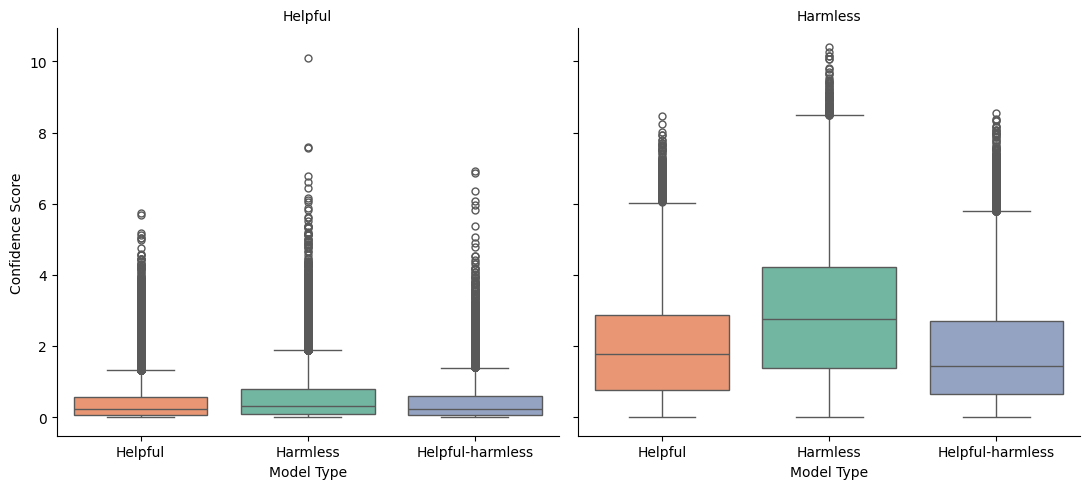

In [28]:
# Define consistent colors for each model type
model_types = sorted(df["model_type"].unique())
palette = dict(zip(model_types, sns.color_palette("Set2", len(model_types))))

# Create a single figure with two panels
g = sns.catplot(
    data=df,
    x="model_type",
    y="score Confidence",
    col="sub_task",        # one panel per subtask
    kind="box",
    palette=palette,
    height=5,
    aspect=1.1
)

g.set_axis_labels("Model Type", "Confidence Score")
g.set_titles("{col_name}")
plt.savefig(f'save/fig/score_confidence.pdf')
plt.show()

# Neural Score Analysis

## Average scoring by layer

In [44]:
path_chosen = 'save/results/{model_name}_{rm_type}_{seed}/chosen_activation_{score_type}.json'
path_rejected = 'save/results/{model_name}_{rm_type}_{seed}/rejected_activation_{score_type}.json'

scores_chosen = {}
scores_rejected = {}
average_score={}
global_trend={}

for model_name in MODEL_NAMES:
    for score_type in SCORE_TYPE:
        for rm_type in ['helpful','harmless','helpful-harmless']:

            key = f"{model_name}_{rm_type}_{score_type}"

            scores_chosen[key] = []
            scores_rejected[key] = []

            for seed in SEEDS:

                with open(
                    path_chosen.format(
                        model_name=model_name,
                        rm_type=rm_type,
                        seed=seed,
                        score_type=score_type,
                    ),
                    "r",
                ) as f:
                    scores_chosen[key].append(
                        np.array(json.load(f))
                    )

                with open(
                    path_rejected.format(
                        model_name=model_name,
                        rm_type=rm_type,
                        seed=seed,
                        score_type=score_type,
                    ),
                    "r",
                ) as f:
                    scores_rejected[key].append(
                        np.array(json.load(f))
                    )

            # average across seeds
            scores_chosen[key] = np.maximum(np.mean(scores_chosen[key], axis=0),0)
            scores_rejected[key] = np.maximum(np.mean(scores_rejected[key], axis=0),0)
            average_score[key]=np.abs(np.array((scores_chosen[key]+scores_rejected[key])/2))

In [45]:
path_chosen = "save/results/{model_name}_{rm_type}_{seed}/chosen_activation_{score_type}.json"
path_rejected = "save/results/{model_name}_{rm_type}_{seed}/rejected_activation_{score_type}.json"

scores_chosen = {}
scores_rejected = {}
rms_diff = {}
global_trend = {}

for model_name in MODEL_NAMES:
    for score_type in ['absolute']:
        for rm_type in ["helpful", "harmless",'helpful-harmless']:

            key = f"{model_name}_{rm_type}_{score_type}"

            chosen_seeds = []
            rejected_seeds = []

            for seed in SEEDS:
                with open(
                    path_chosen.format(
                        model_name=model_name,
                        rm_type=rm_type,
                        seed=seed,
                        score_type=score_type,
                    ),
                    "r",
                ) as f:
                    chosen_seeds.append(np.array(json.load(f)))

                with open(
                    path_rejected.format(
                        model_name=model_name,
                        rm_type=rm_type,
                        seed=seed,
                        score_type=score_type,
                    ),
                    "r",
                ) as f:
                    rejected_seeds.append(np.array(json.load(f)))

            # ---- average across seeds ----
            chosen_mean = np.mean(chosen_seeds, axis=0)
            rejected_mean = np.mean(rejected_seeds, axis=0)

            # optional: clamp negatives if scores are non-negative by design
            # chosen_mean = np.maximum(chosen_mean, 0)
            # rejected_mean = np.maximum(rejected_mean, 0)

            scores_chosen[key] = chosen_mean
            scores_rejected[key] = rejected_mean

            # ---- RMS difference (per neuron) ----
            diff = chosen_mean - rejected_mean
            rms_diff[key] = np.sqrt(np.mean(diff ** 2, axis=0))

            # ---- global scalar trend ----
            global_trend[key] = np.mean(rms_diff[key])

In [46]:
global_trend

{'smollm2-1.7b_helpful_absolute': np.float64(0.0029779239693167544),
 'smollm2-1.7b_harmless_absolute': np.float64(0.004483962243136554),
 'smollm2-1.7b_helpful-harmless_absolute': np.float64(0.0037329551298570978),
 'smollm2-135m_helpful_absolute': np.float64(0.0027212164176967555),
 'smollm2-135m_harmless_absolute': np.float64(0.004797705545534916),
 'smollm2-135m_helpful-harmless_absolute': np.float64(0.002746996090753335),
 'smollm2-360m_helpful_absolute': np.float64(0.0027515161028500864),
 'smollm2-360m_harmless_absolute': np.float64(0.004813264908016061),
 'smollm2-360m_helpful-harmless_absolute': np.float64(0.0028798709122570773),
 'gpt2-small_helpful_absolute': np.float64(0.0013125220549254763),
 'gpt2-small_harmless_absolute': np.float64(0.0024433972382651085),
 'gpt2-small_helpful-harmless_absolute': np.float64(0.001599475876601849),
 'gpt2-medium_helpful_absolute': np.float64(0.0013673305833884558),
 'gpt2-medium_harmless_absolute': np.float64(0.0025751484384510465),
 'gpt2

In [47]:
# colors = {
#     "helpful": "#5D88B6",
#     "harmless": "#34A334",
#     # "helpful-harmless": "#AC49AF"
# }

# linestyles = ["-", "--", "-.", ":"]
# markers = ["o", "s", "^", "D", "v", "x"]
# models = sorted({
#     "_".join(k.split("_")[:-2])
#     for k in scores_chosen
# })
# style_cycle = zip(
#     itertools.cycle(linestyles),
#     itertools.cycle(markers)
# )

# styles = {model: next(style_cycle) for model in models}

# # -----------------------
# # FIGURE
# # -----------------------
# fig, axes = plt.subplots(2, len(SCORE_TYPE), figsize=(14, 8), sharey=True)

# for col, score_type in enumerate(SCORE_TYPE):
#     # top row: chosen
#     ax_chosen = axes[0, col]
#     # bottom row: rejected
#     ax_rejected = axes[1, col]

#     for key, values in scores_chosen.items():
#         parts = key.split("_")
#         model = "_".join(parts[:-2])
#         training = parts[-2]
#         stype = parts[-1]

#         if stype != score_type:
#             continue

#         scores = values.mean(axis=1)
#         linestyle, marker = styles[model]
#         x = range(len(scores))

#         ax_chosen.plot(
#             x,
#             scores,
#             color=colors[training],
#             linestyle=linestyle,
#             marker=marker,
#         )

#     ax_chosen.set_title(f"{score_type.capitalize()} score (Chosen)")
#     ax_chosen.set_xlabel("Layer")
#     ax_chosen.grid(alpha=0.3)

#     for key, values in scores_rejected.items():
#         parts = key.split("_")
#         model = "_".join(parts[:-2])
#         training = parts[-2]
#         stype = parts[-1]

#         if stype != score_type:
#             continue

#         scores = values.mean(axis=1)
#         linestyle, marker = styles[model]
#         x = range(len(scores))

#         ax_rejected.plot(
#             x,
#             scores,
#             color=colors[training],
#             linestyle=linestyle,
#             marker=marker,
#         )

#     ax_rejected.set_title(f"{score_type.capitalize()} score (Rejected)")
#     ax_rejected.set_xlabel("Layer")
#     ax_rejected.grid(alpha=0.3)

# axes[0,0].set_ylabel("Score")
# axes[1,0].set_ylabel("Score")

# # -----------------------
# # LEGEND
# # -----------------------
# training_legend = [
#     Line2D([0], [0], color=c, lw=3, label=t)
#     for t, c in colors.items()
# ]

# model_legend = [
#     Line2D(
#         [0], [0],
#         color="black",
#         linestyle=styles[m][0],
#         marker=styles[m][1],
#         label=m,
#     )
#     for m in styles
# ]

# fig.legend(
#     handles=training_legend + model_legend,
#     loc="lower center",
#     ncol=5,
#     frameon=False,
#     bbox_to_anchor=(0.5, -0.05),
# )

# plt.tight_layout()
# plt.show()

In [48]:
# correlations_per_neuron = {}

# # Iterate over model+training combinations (base keys)
# keys_base = {"_".join(k.split("_")[:-1]) for k in scores_chosen}

# for base in keys_base:
#     # full keys for change and absolute
#     change_key = f"{base}_change"
#     absolute_key = f"{base}_absolute"

#     if change_key not in scores_chosen or absolute_key not in scores_chosen:
#         continue

#     # average across chosen and rejected
#     avg_change = average_score[change_key]
#     avg_absolute = average_score[absolute_key]

#     # Flatten per neuron across all layers
#     # assumes avg_change[layer] shape = (num_neurons,)
#     neurons_change = np.concatenate(list(avg_change))
#     neurons_absolute = np.concatenate(list(avg_absolute))

#     # correlation across neurons
#     corr = np.corrcoef(neurons_change, neurons_absolute)[0, 1]

#     correlations_per_neuron[base] = corr

# # Print results
# print("Correlation per neuron between CHANGE and ABSOLUTE scores (all neurons):")
# for key, corr in correlations_per_neuron.items():
#     print(f"{key}: {corr:.4f}")

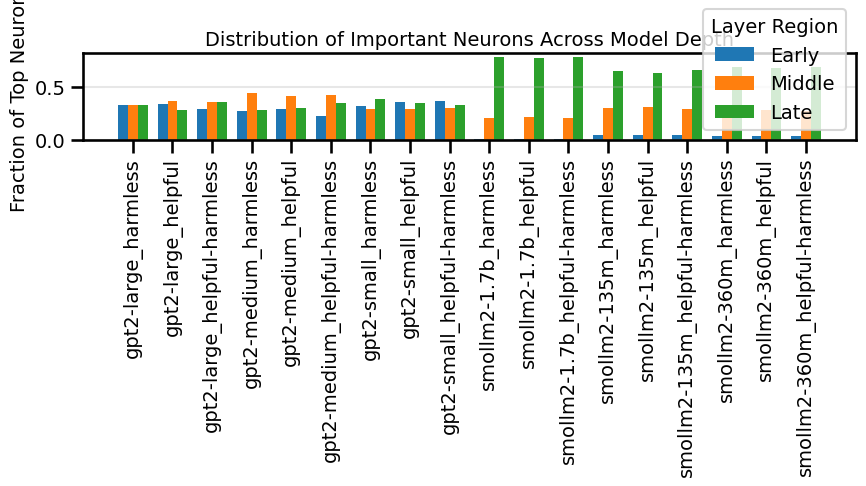

In [49]:
activation_top_neurons = {'model':[],'layer':[],'index':[],'change_in_activation':[]}
keys_base = set("_".join(k.split("_")[:-1]) for k in scores_chosen.keys())
for base in keys_base:
    change_key = f"{base}_change"
    absolute_key = f"{base}_absolute"

    avg_change = average_score[change_key]
    avg_absolute = average_score[absolute_key]

    top_absolute = np.array(list(get_top_indices(avg_absolute,10)))
    layer=list(top_absolute[:,0])
    index=list(top_absolute[:,1])
    change_in_activations=avg_absolute[top_absolute[:,0],top_absolute[:,1]]
    activation_top_neurons['model'].extend([base]*len(layer))
    activation_top_neurons['index'].extend(index)
    activation_top_neurons['layer'].extend(layer)
    activation_top_neurons['change_in_activation'].extend(change_in_activations)
top_neurons_information=pd.DataFrame(activation_top_neurons)
# get total layers per model
num_layers_per_model = (
    top_neurons_information
    .groupby('model')['layer']
    .max()
    .to_dict()
)

# function assigning region
def assign_layer_region(row):
    max_layer = num_layers_per_model[row['model']] + 1

    third = max_layer / 3

    if row['layer'] < third:
        return "early"
    elif row['layer'] < 2 * third:
        return "middle"
    else:
        return "late"

top_neurons_information['layer_region'] = (
    top_neurons_information.apply(assign_layer_region, axis=1)
)

region_counts = (
    top_neurons_information
    .groupby(['model', 'layer_region'])
    .size()
    .reset_index(name='count')
)

# normalize
region_counts['fraction'] = (
    region_counts
    .groupby('model')['count']
    .transform(lambda x: x / x.sum())
)

regions = ["early", "middle", "late"]

# pivot table
pivot = (
    region_counts
    .pivot(index='model', columns='layer_region', values='fraction')
    .fillna(0)[regions]
)

models = pivot.index.tolist()

x = np.arange(len(models))
width = 0.25  # bar width

plt.figure(figsize=(9,5))

# 3 bars per model
for i, region in enumerate(regions):
    plt.bar(
        x + i * width,
        pivot[region],
        width,
        label=region.capitalize()
    )

plt.xticks(x + width, models, rotation=90)
plt.ylabel("Fraction of Top Neurons")
plt.title("Distribution of Important Neurons Across Model Depth")
plt.legend(title="Layer Region")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

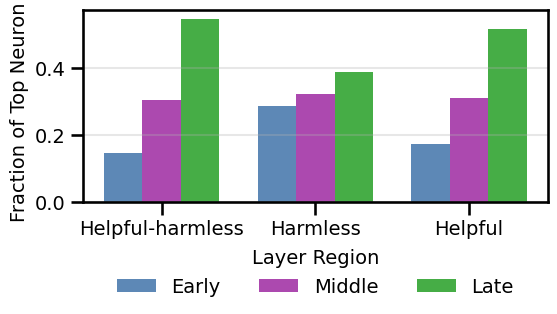

In [50]:
def extract_rm_type(model_name):
    if 'helpful-harmless' in model_name:
        return "Helpful-harmless"
    if "helpful" in model_name:
        return "helpful"
    elif "harmless" in model_name:
        return "harmless"
    else:
        return "unknown"

top_neurons_information["rm_type"] = (
    top_neurons_information["model"].apply(extract_rm_type)
)
global_region_counts = (
    top_neurons_information
    .groupby(["rm_type", "layer_region"])
    .size()
    .reset_index(name="count")
)
global_region_counts["fraction"] = (
    global_region_counts
    .groupby("rm_type")["count"]
    .transform(lambda x: x / x.sum())
)
regions = ["early", "middle", "late"]

global_pivot = (
    global_region_counts
    .pivot(index="rm_type", columns="layer_region", values="fraction")
    .fillna(0)[regions]
)
x = np.arange(len(global_pivot.index))
width = 0.1

# Fun color palette (distinct but paper-friendly)
colors = {
    "early":"#5D88B6",   # slate blue
    "middle": "#AC49AF",  # dark orange
    "late": "#46AD46",    # sea green
}

x = np.arange(len(global_pivot.index))
width = 0.25

plt.figure(figsize=(6,2.5))

for i, region in enumerate(regions):
    plt.bar(
        x + i * width,
        global_pivot[region],
        width,
        label=region.capitalize(),
        color=colors[region]
    )

plt.xticks(x + width, global_pivot.index.str.capitalize())
plt.ylabel("Fraction of Top Neuron  ")
plt.legend(
    title="Layer Region",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False
)

plt.grid(axis="y", alpha=0.3)
plt.savefig('save/fig/layerwise_distribution.pdf',bbox_inches="tight",)
plt.show()

In [51]:
top_neurons_information['model_type']=top_neurons_information['model'].str.split("_").str[-1]
top_neurons_information['model_name']=top_neurons_information['model'].str.split("_").str[0]
top_neurons_information["layer_index"] = (
    top_neurons_information["layer"].astype(str)
    + "_"
    + top_neurons_information["index"].astype(str)
)

In [52]:
import pandas as pd

grouped = top_neurons_information.groupby(["model_name", "model_type"])["layer_index"].apply(set)

models = top_neurons_information["model_name"].unique()
types = top_neurons_information["model_type"].unique()

results = []

for model in models:
    model_types = [t for t in types if (model, t) in grouped.index]

    for i in range(len(model_types)):
        for j in range(i + 1, len(model_types)):

            t1, t2 = model_types[i], model_types[j]

            A = grouped[(model, t1)]
            B = grouped[(model, t2)]

            intersection = A & B
            union = A | B

            jaccard = len(intersection) / len(union) if len(union) > 0 else 0.0

            results.append({
                "model": model,
                "type_1": t1,
                "type_2": t2,
                "jaccard": jaccard,
                "intersection_size": len(intersection),
                "union_size": len(union)
            })

jaccard_df = pd.DataFrame(results)

In [53]:
results

[{'model': 'smollm2-360m',
  'type_1': 'helpful-harmless',
  'type_2': 'helpful',
  'jaccard': 0.8265328874024526,
  'intersection_size': 7414,
  'union_size': 8970},
 {'model': 'smollm2-360m',
  'type_1': 'helpful-harmless',
  'type_2': 'harmless',
  'jaccard': 0.706133499947933,
  'intersection_size': 6781,
  'union_size': 9603},
 {'model': 'smollm2-360m',
  'type_1': 'helpful',
  'type_2': 'harmless',
  'jaccard': 0.6648714561528299,
  'intersection_size': 6543,
  'union_size': 9841},
 {'model': 'gpt2-medium',
  'type_1': 'helpful-harmless',
  'type_2': 'helpful',
  'jaccard': 0.4719269351699356,
  'intersection_size': 6304,
  'union_size': 13358},
 {'model': 'gpt2-medium',
  'type_1': 'helpful-harmless',
  'type_2': 'harmless',
  'jaccard': 0.42840537595350525,
  'intersection_size': 5897,
  'union_size': 13765},
 {'model': 'gpt2-medium',
  'type_1': 'helpful',
  'type_2': 'harmless',
  'jaccard': 0.39081841974959325,
  'intersection_size': 5525,
  'union_size': 14137},
 {'model': 

In [63]:
jaccard_df

,model,type_1,type_2,jaccard,intersection_size,union_size
0,smollm2-360m,helpful-harmless,helpful,0.826533,7414,8970
1,smollm2-360m,helpful-harmless,harmless,0.706133,6781,9603
2,smollm2-360m,helpful,harmless,0.664871,6543,9841
3,gpt2-medium,helpful-harmless,helpful,0.471927,6304,13358
4,gpt2-medium,helpful-harmless,harmless,0.428405,5897,13765
5,gpt2-medium,helpful,harmless,0.390818,5525,14137
6,smollm2-1.7b,helpful-harmless,helpful,0.722836,16498,22824
7,smollm2-1.7b,helpful-harmless,harmless,0.612747,14940,24382
8,smollm2-1.7b,helpful,harmless,0.591082,14608,24714
9,smollm2-135m,helpful-harmless,helpful,0.829661,4179,5037


In [57]:
jaccard_df.groupby(['type_1','type_2'])['jaccard'].mean()

type_1            type_2  
helpful           harmless    0.476967
helpful-harmless  harmless    0.499250
                  helpful     0.607420
Name: jaccard, dtype: float64

In [60]:
combined_results = []

for model in models:
    required_types = ["helpful", "harmless", "helpful-harmless"]

    if all((model, t) in grouped.index for t in required_types):

        helpful = grouped[(model, "helpful")]
        harmless = grouped[(model, "harmless")]
        both = grouped[(model, "helpful-harmless")]

        # numerator: (helpful ∪ harmless) ∩ (helpful-harmless)
        numerator = (helpful | harmless) & both

        # denominator: union of all three
        denominator = helpful | harmless | both

        score = len(numerator) / len(denominator) if len(denominator) > 0 else 0.0

        combined_results.append({
            "model": model,
            "custom_jaccard": score,
            "numerator_size": len(numerator),
            "denominator_size": len(denominator)
        })

combined_custom_df = pd.DataFrame(combined_results)


In [62]:
combined_custom_df['custom_jaccard'].mean()

np.float64(0.5488500021833749)

# Abalation Effect

## Performance on traning dataset

In [36]:
MODEL_NAMES

['smollm2-1.7b',
 'smollm2-135m',
 'smollm2-360m',
 'gpt2-small',
 'gpt2-medium',
 'gpt2-large']

In [37]:
import json

model_attention_head_info={
    # 'pythia-70m':(6,8),
    # 'pythia-1b':(16,8),
'gpt2-small':(12,12)
}
df_model_name=[]
df_sub_task=[]
df_dataset_name=[]
df_varence=[]
df_accuracy=[]
df_model_type=[]
df_p=[]
df_abalation_types=[]
for abalation_type in ABALATION_TYPE:
    for p in [0,
               2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,100
              ]:
        for model_name in MODEL_NAMES:
            for rm_dataset_type in ['helpful','harmless','helpful-harmless']:
                for bench_dataset in ['hh-rlhf']:
                    accuracy_dictionary=[]
                    # for seed in seeds:
                    for seed in SEEDS:
                        if p!=0:
                            path_name=f'./save/results/{model_name}_{rm_dataset_type}_{seed}/{bench_dataset}-{rm_dataset_type}_ab={abalation_type}_per={p}.json'
                        else:
                            path_name=f'./save/results/{model_name}_{rm_dataset_type}_{seed}/{bench_dataset}-{rm_dataset_type}.json'
                        with open(path_name, "r") as f:
                            load_dict = json.load(f)
                        # sub_set=subsub_set[bench_dataset]
                        results=load_dict['results']
                        accuracy=sum(results)/len(results)*100
                        accuracy_dictionary.append(accuracy)

                    df_model_name.append(model_name)
                    df_dataset_name.append(bench_dataset)
                    df_varence.append(float(np.std(accuracy_dictionary)))
                    df_accuracy.append(float(np.mean(accuracy_dictionary)))
                    df_model_type.append(rm_dataset_type)
                    df_p.append(p)
                    df_abalation_types.append(abalation_type)


df=pd.DataFrame(
    {
        'model_name':df_model_name,
        'dataset_name':df_dataset_name,
        'varence':df_varence,
        'accuracy':df_accuracy,
        'rm_type':df_model_type,
        'p':df_p,
        'abalation_type':df_abalation_types
    }
)

In [38]:
df.to_csv('save/results/abalation_results.csv')

In [39]:
df = pd.read_csv('save/results/abalation_results.csv')

# Ensure numeric
df["accuracy"] = pd.to_numeric(df["accuracy"], errors="coerce")
df["p"] = pd.to_numeric(df["p"], errors="coerce")

group_cols = ["model_name", "dataset_name", "rm_type", "abalation_type"]

# Get baselines
base_100 = df[df["p"] == 100][group_cols + ["accuracy"]] \
    .rename(columns={"accuracy": "acc_p100"})

base_0 = df[df["p"] == 0][group_cols + ["accuracy"]] \
    .rename(columns={"accuracy": "acc_p0"})

# Merge baselines
df = df.merge(base_100, on=group_cols, how="left")
df = df.merge(base_0, on=group_cols, how="left")

# Avoid division by zero
eps = 1e-8

# New normalized score (recommended single metric)
df["normalized_score"] = (
    (df["accuracy"] - 50) /
    (df["acc_p0"] - 50 + eps)
)

# Refrence and drop scores
df["reference_score"] = 1 - (df["accuracy"] / (50 + eps))
df["drop_score"] = 1 - (df["accuracy"] / (df["acc_p0"] + eps))

# Filter for plotting
df_plot = df[~df["p"].isin([0, 100])]

In [40]:
df_plot.head()

,Unnamed: 0,model_name,dataset_name,varence,accuracy,rm_type,p,abalation_type,acc_p100,acc_p0,normalized_score,reference_score,drop_score
18,18,smollm2-1.7b,hh-rlhf,0.440565,74.100821,helpful,2,random_activations,50.679694,74.525630,0.982679,-0.482016,0.005700
19,19,smollm2-1.7b,hh-rlhf,0.040779,73.688005,harmless,2,random_activations,38.264129,73.745675,0.997571,-0.473760,0.000782
20,20,smollm2-1.7b,hh-rlhf,0.454409,73.024718,helpful-harmless,2,random_activations,49.678526,73.174739,0.993527,-0.460494,0.002050
21,21,smollm2-135m,hh-rlhf,0.105966,70.631549,helpful,2,random_activations,41.971113,70.320023,1.015331,-0.412631,-0.004430
22,22,smollm2-135m,hh-rlhf,0.474247,70.559400,harmless,2,random_activations,48.269896,70.617070,0.997203,-0.411188,0.000817


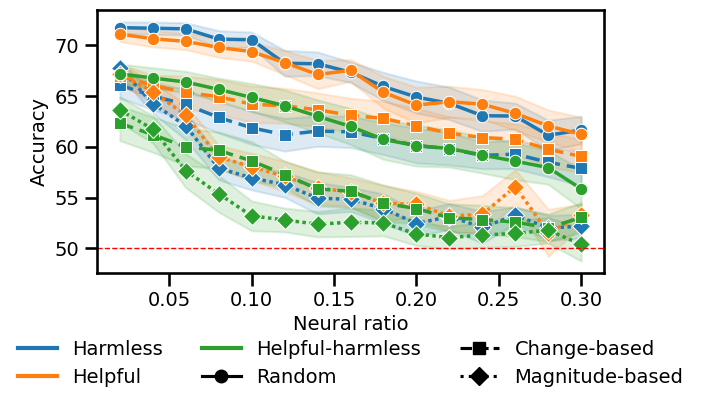

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# -----------------------
# Aggregate across models
# -----------------------
df_agg = (
    df_plot
    .groupby(["dataset_name", "rm_type", "abalation_type", "p"], as_index=False)
    .agg(
        mean_accuracy=("accuracy", "mean"),
        mean_variance=("varence", "mean"),
    )
)

df_agg["std_accuracy"] = np.sqrt(df_agg["mean_variance"])
df_agg["Neural ratio"] = df_agg["p"] / 100
df_agg["Single Objective Model"] = df_agg["rm_type"]

df_agg["Abalation Type"] = df_agg["abalation_type"].replace({
    "random_activations": "Random",
    "top_activations": "Change-based",
    "top_activations_absolute": "Magnitude-based",
})

# -----------------------
# Palette
# -----------------------
rm_types = df_agg["Single Objective Model"].unique()
palette = dict(zip(rm_types, sns.color_palette("tab10", len(rm_types))))

# -----------------------
# FIX style mappings
# -----------------------
markers_map = {
    "Random": "o",
    "Change-based": "s",
    "Magnitude-based": "D",
}

dashes_map = {
    "Random": (1, 0),
    "Change-based": (4, 2),
    "Magnitude-based": (1, 1),
}

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(7, 5))

ax = sns.lineplot(
    data=df_agg,
    x="Neural ratio",
    y="mean_accuracy",
    hue="Single Objective Model",
    style="Abalation Type",
    palette=palette,
    markers=markers_map,
    dashes=dashes_map,
    linewidth=2.5,
)

# -----------------------
# Variance shading
# -----------------------
for (rm, ab), sub_df in df_agg.groupby(
    ["Single Objective Model", "Abalation Type"]
):
    sub_df = sub_df.sort_values("Neural ratio")

    std = np.sqrt(sub_df["mean_variance"])

    plt.fill_between(
        sub_df["Neural ratio"],
        sub_df["mean_accuracy"] - std,
        sub_df["mean_accuracy"] + std,
        color=palette[rm],
        alpha=0.15,
    )

# -----------------------
# Chance line
# -----------------------
plt.axhline(y=50.0, color="red", linestyle="--", linewidth=1)

plt.ylabel("Accuracy")
plt.xlabel("Neural ratio")

# -----------------------
# Legend (FIXED)
# -----------------------

# color legend
training_legend = [
    Line2D([0], [0], color=palette[rm], lw=3, label=rm.capitalize())
    for rm in rm_types
]

# linestyle legend (safe for matplotlib)
linestyle_map = {
    "Random": "-",
    "Change-based": "--",
    "Magnitude-based": ":",
}

abalation_types = list(markers_map.keys())

model_legend = [
    Line2D(
        [0], [0],
        color="black",
        linestyle=linestyle_map[ab],
        marker=markers_map[ab],
        label=ab,
    )
    for ab in abalation_types
]

plt.legend(
    handles=training_legend + model_legend,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.5),
)

plt.tight_layout()
plt.savefig('save/fig/ablation_effect.pdf', bbox_inches="tight")
plt.show()

In [42]:
df_plot[df_plot['p']==10]["drop_score"].mean()*100

np.float64(11.52234151622896)

In [43]:
df_plot[df_plot['p']==20]["drop_score"].mean()*100

np.float64(16.91764355202364)

In [44]:
df_plot[df_plot['p']==30]["drop_score"].mean()*100

np.float64(19.91638811729361)

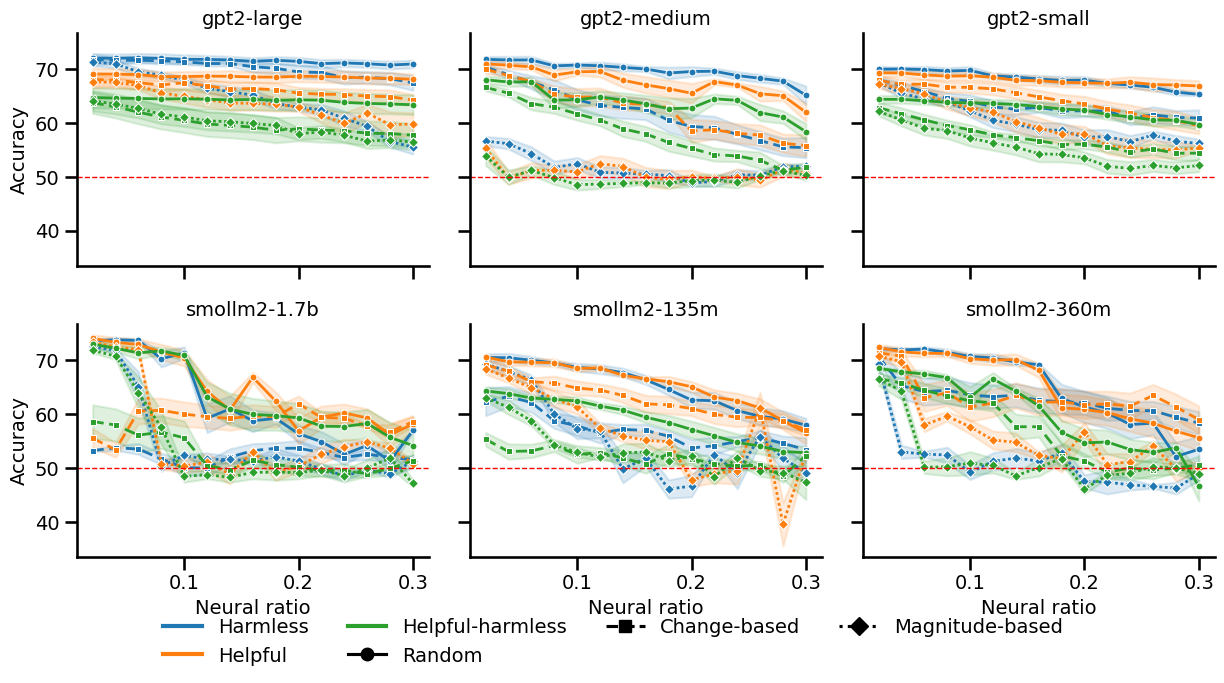

In [45]:

df_agg = (
    df_plot
    .groupby(["model_name", "dataset_name", "rm_type", "abalation_type", "p"], as_index=False)
    .agg(
        mean_accuracy=("accuracy", "mean"),
        mean_variance=("varence", "mean"),
    )
)

df_agg["std_accuracy"] = np.sqrt(df_agg["mean_variance"])
df_agg["Neural ratio"] = df_agg["p"] / 100
df_agg["Single Objective Model"] = df_agg["rm_type"]

df_agg["Abalation Type"] = df_agg["abalation_type"].replace({
    "random_activations": "Random",
    "top_activations": "Change-based",
    "top_activations_absolute": "Magnitude-based",
})

# -----------------------
# Palette
# -----------------------
rm_types = df_agg["Single Objective Model"].unique()
palette = dict(zip(rm_types, sns.color_palette("tab10", len(rm_types))))

# -----------------------
# Style maps (FIXED)
# -----------------------
markers_map = {
    "Random": "o",
    "Change-based": "s",
    "Magnitude-based": "D",
}

dashes_map = {
    "Random": (1, 0),
    "Change-based": (4, 2),
    "Magnitude-based": (1, 1),
}

# -----------------------
# Facet grid
# -----------------------
g = sns.relplot(
    data=df_agg,
    x="Neural ratio",
    y="mean_accuracy",
    hue="Single Objective Model",
    style="Abalation Type",
    col="model_name",
    col_wrap=3,
    kind="line",
    palette=palette,
    markers=markers_map,
    dashes=dashes_map,
    linewidth=2.0,
    height=3.5,
    aspect=1.2,
    legend=False,
)

# -----------------------
# Variance shading + chance line
# -----------------------
for ax, (model, sub_df_model) in zip(g.axes.flat, df_agg.groupby("model_name")):

    for (rm, ab), sub_df in sub_df_model.groupby(
        ["Single Objective Model", "Abalation Type"]
    ):
        sub_df = sub_df.sort_values("Neural ratio")

        std = np.sqrt(sub_df["mean_variance"])

        ax.fill_between(
            sub_df["Neural ratio"],
            sub_df["mean_accuracy"] - std,
            sub_df["mean_accuracy"] + std,
            color=palette[rm],
            alpha=0.15,
        )

    ax.axhline(y=50.0, color="red", linestyle="--", linewidth=1)

    ax.set_title(model)
    ax.set_xlabel("Neural ratio")
    ax.set_ylabel("Accuracy")

    # consistent marker size
    for line in ax.lines:
        line.set_markersize(5)

# -----------------------
# Legend (FIXED)
# -----------------------

# color legend
training_legend = [
    Line2D([0], [0], color=palette[rm], lw=3, label=rm.capitalize())
    for rm in rm_types
]

# linestyle legend (IMPORTANT FIX)
linestyle_map = {
    "Random": "-",
    "Change-based": "--",
    "Magnitude-based": ":",
}

abalation_types = list(markers_map.keys())

model_legend = [
    Line2D(
        [0], [0],
        color="black",
        linestyle=linestyle_map[ab],
        marker=markers_map[ab],
        label=ab,
    )
    for ab in abalation_types
]

g.fig.legend(
    handles=training_legend + model_legend,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0),
)

plt.subplots_adjust(bottom=0.18)

# -----------------------
# Save
# -----------------------
plt.savefig("save/fig/ablation_grid.pdf", bbox_inches="tight")
plt.show()

# Performance on other tasks.

In [10]:
df_model_name=[]
df_sub_task=[]
df_dataset_name=[]
df_varence=[]
df_accuracy=[]
df_model_type=[]
df_p=[]
df_abalation_types=[]
for model_name in MODEL_NAMES:
    for rm_dataset_type in ['helpful','harmless','helpful-harmless']:
        for bench_dataset in BENCH_DATASETS:
            for abalation_type in ['top_activations_absolute']:
                for p in [
                    0,
                    # 5,
                    10,
                    # 20
                    ]:
                    accuracy_dictionary={}
                    for seed in SEEDS:
                        if p==0:
                            path_name=path_name=f'./save/results/{model_name}_{rm_dataset_type}_{seed}/{bench_dataset}.json'
                        else:
                            path_name=f'./save/results/{model_name}_{rm_dataset_type}_{seed}/{bench_dataset}_ab={abalation_type}_per={p}.json'
                        with open(path_name, "r") as f:
                            load_dict = json.load(f)
                        sub_set=subsub_set[bench_dataset]
                        results=load_dict['results']
                        indexed_results=rej_index_dic=defaultdict(list)
                        for item,idx in zip(results,sub_set):
                            indexed_results[idx].append(item)
                        for key,value in indexed_results.items():
                            accuracy=sum(value)/len(value)*100

                            if key in accuracy_dictionary:
                                accuracy_dictionary[key].append(accuracy)
                            else:
                                accuracy_dictionary[key]=[accuracy]

                    for key,value in accuracy_dictionary.items():
                        if key.lower() in SUB_TASK_2_AVOIDE:
                            continue
                        else:
                            df_model_name.append(model_name)
                            df_sub_task.append(key)
                            df_dataset_name.append(bench_dataset)
                            df_varence.append(float(np.std(value)))
                            df_accuracy.append(float(np.mean(value)))
                            df_model_type.append(rm_dataset_type)
                            df_p.append(p)
                            df_abalation_types.append(abalation_type)


df=pd.DataFrame(
    {
        'model_name':df_model_name,
        'sub_task':df_sub_task,
        'dataset_name':df_dataset_name,
        'varence':df_varence,
        'accuracy':df_accuracy,
        'rm_type':df_model_type,
        'p':df_p,
        'abalation_types':df_abalation_types
    }
)
group_cols = [
    "rm_type",
    "p",
    "abalation_types",
    "sub_task",
    "dataset_name",
]

avg_df = (
    df
    .groupby(group_cols, as_index=False)
    .agg(
        accuracy=("accuracy", "mean"),
        varence=("varence", "mean"),
    )
)
avg_df["model_name"] = "model_average"
avg_df = avg_df[df.columns]  # reorder to match original df
df = pd.concat([df, avg_df], ignore_index=True)
df['sub_task']=df['sub_task'].replace(NORMALISED_SUB_TYPE)
df.to_csv('save/results/abalation_HH_results.csv')

In [11]:
df['rm_type'].unique()

<ArrowStringArray>
['helpful', 'harmless', 'helpful-harmless']
Length: 3, dtype: str

In [12]:
# Map task type
df["task_type"] = df["sub_task"].map(TYPE_SUB_TASK)
df = df.dropna(subset=["task_type"])

df = df.drop(columns=["dataset_name"], errors="ignore")

############################################
# AGGREGATE (KEEP task_type!)
############################################

df = (
    df.groupby(
        [
            "rm_type",
            "model_name",
            "sub_task",
            "task_type",
            "p",
            "abalation_types",
        ],
        as_index=False
    )["accuracy"]
    .mean()
)

############################################
# BASELINE (p = 0)
############################################

baseline = (
    df[df["p"] == 0]
    .rename(columns={"accuracy": "baseline_acc"})
    [
        [
            "rm_type",
            "model_name",
            "sub_task",
            "task_type",
            "baseline_acc"
        ]
    ]
)

############################################
# HELPERS
############################################

def rotate(text):
    return f"\\rotatebox{{90}}{{{text}}}"


def color_delta(x, tol=1e-6):
    if x < -tol:
        return f"\\cellcolor{{red!20}}{x:+.2f}"
    else:
        return f"\\cellcolor{{blue!20}}{x:+.2f}"


############################################
# LATEX TABLE BUILDER
############################################

def make_latex_table(df_p, p_val):

    task_type = df_p["task_type"].iloc[0]

    sub_tasks = sorted(df_p["sub_task"].unique())
    rm_types = sorted(df_p["rm_type"].unique())
    print(rm_types)

    header = " & ".join(rotate(s) for s in sub_tasks)

    latex = []

    latex.append("\\begin{table*}[t]")
    latex.append("\\centering")
    latex.append("\\setlength{\\tabcolsep}{3pt}")
    latex.append("\\renewcommand{\\arraystretch}{1.1}")
    latex.append("\\begin{adjustbox}{max width=\\textwidth}")
    latex.append("\\begin{tabular}{l|" + "c"*len(sub_tasks) + "|c}")
    latex.append("\\hline")

    latex.append(f"Model & {header} & Avg \\\\")
    latex.append("\\hline")

    ############################################
    # RM TYPE GROUPING
    ############################################

    for rm in rm_types:

        rm_df = df_p[df_p["rm_type"] == rm]

        if rm_df.empty:
            continue

        latex.append(
            f"\\multicolumn{{{len(sub_tasks)+2}}}{{c}}"
            f"{{\\cellcolor[HTML]{{DDDDDD}}\\textbf{{{rm.upper()}}}}}\\\\"
        )

        models = sorted(rm_df["model_name"].unique())

        for model in models:

            model_df = rm_df[rm_df["model_name"] == model]

            latex.append(
                f"\\multicolumn{{{len(sub_tasks)+2}}}{{l}}"
                f"{{\\cellcolor[HTML]{{EEEEEE}}{model}}}\\\\"
            )

            # ---------------- BASELINE ----------------
            base = (
                model_df.drop_duplicates("sub_task")
                .set_index("sub_task")["baseline_acc"]
            )

            baseline_vals = [base[s] for s in sub_tasks]
            baseline_avg = sum(baseline_vals) / len(baseline_vals)

            latex.append(
                "\\textbf{Baseline} & "
                + " & ".join(f"{v:.2f}" for v in baseline_vals)
                + f" & {baseline_avg:.2f} \\\\"
            )

            latex.append("\\hdashline")

            # ---------------- ABLATIONS ----------------
            for abl in sorted(model_df["abalation_types"].unique()):

                abl_df = (
                    model_df[
                        model_df["abalation_types"] == abl
                    ].set_index("sub_task")
                )
                print(abl_df)
                deltas = []
                formatted = []

                for s in sub_tasks:
                    d = abl_df.loc[s, "delta"]
                    deltas.append(d)
                    formatted.append(color_delta(d))

                avg_delta = sum(deltas) / len(deltas)

                latex.append(
                    f"$(-)\\ {abl}$ & "
                    + " & ".join(formatted)
                    + f" & {color_delta(avg_delta)} \\\\"
                )

            latex.append("\\hline")

    latex.append("\\end{tabular}")
    latex.append("\\end{adjustbox}")

    latex.append(
        f"\\caption{{Performance change relative to baseline ($p=0$) "
        f"for $p={p_val}$ on \\textbf{{{task_type}}} tasks.}}"
    )

    latex.append(
        f"\\label{{tab:ablation_p{p_val}_{task_type}}}"
    )

    latex.append("\\end{table*}")

    return "\n".join(latex)


############################################
# GENERATION LOOP
############################################

for p_val in sorted(df["p"].unique()):

    if p_val == 0:
        continue

    df_p = df[df["p"] == p_val].merge(
        baseline,
        on=["rm_type", "model_name", "sub_task", "task_type"]
    )

    df_p["delta"] = df_p["accuracy"] - df_p["baseline_acc"]

    # split into harmless / hateful tables
    for task_type, df_split in df_p.groupby("task_type"):

        latex = make_latex_table(df_split, p_val)

        with open(
            f"table_p{p_val}_{task_type}.tex",
            "w"
        ) as f:
            f.write(latex)

['harmless', 'helpful', 'helpful-harmless']
                        rm_type  model_name task_type   p  \
sub_task                                                    
Do Not Answer          harmless  gpt2-large  Harmless  10   
Refusals Dangerous     harmless  gpt2-large  Harmless  10   
Refusals Offensive     harmless  gpt2-large  Harmless  10   
Safety                 harmless  gpt2-large  Harmless  10   
Safety Refuse          harmless  gpt2-large  Harmless  10   
Safety Response        harmless  gpt2-large  Harmless  10   
XStest Should Refuse   harmless  gpt2-large  Harmless  10   
XStest Should Respond  harmless  gpt2-large  Harmless  10   

                                abalation_types    accuracy  baseline_acc  \
sub_task                                                                    
Do Not Answer          top_activations_absolute   86.029412     86.764706   
Refusals Dangerous     top_activations_absolute  100.000000    100.000000   
Refusals Offensive     top_activation

In [13]:
BENCH_DATASETS

['rm-bench', 'reward_bench', 'reward_bench2']

In [14]:
df_model_name=[]
df_sub_task=[]
df_dataset_name=[]
df_varence=[]
df_accuracy=[]
df_model_type=[]
df_p=[]
df_abalation_types=[]
for model_name in MODEL_NAMES:
    for rm_dataset_type in ['helpful-harmless']:
        for bench_dataset in BENCH_DATASETS:
            for abalation_type in ABALATION_TYPE2:
                for p in [0,5,10,20]:
                    accuracy_dictionary={}
                    for seed in SEEDS:
                        if p==0:
                            path_name=path_name=f'./save/results/{model_name}_{rm_dataset_type}_{seed}/{bench_dataset}.json'
                        else:
                            path_name=f'./save/results/{model_name}_{rm_dataset_type}_{seed}/{bench_dataset}_ab={abalation_type}_per={p}.json'
                        with open(path_name, "r") as f:
                            load_dict = json.load(f)
                        sub_set=subsub_set[bench_dataset]
                        results=load_dict['results']
                        indexed_results=rej_index_dic=defaultdict(list)
                        for item,idx in zip(results,sub_set):
                            indexed_results[idx].append(item)
                        for key,value in indexed_results.items():
                            accuracy=sum(value)/len(value)*100

                            if key in accuracy_dictionary:
                                accuracy_dictionary[key].append(accuracy)
                            else:
                                accuracy_dictionary[key]=[accuracy]

                    for key,value in accuracy_dictionary.items():
                        if key.lower() in SUB_TASK_2_AVOIDE:
                            continue
                        else:
                            df_model_name.append(model_name)
                            df_sub_task.append(key)
                            df_dataset_name.append(bench_dataset)
                            df_varence.append(float(np.std(value)))
                            df_accuracy.append(float(np.mean(value)))
                            df_model_type.append(rm_dataset_type)
                            df_p.append(p)
                            df_abalation_types.append(abalation_type)


df=pd.DataFrame(
    {
        'model_name':df_model_name,
        'sub_task':df_sub_task,
        'dataset_name':df_dataset_name,
        'varence':df_varence,
        'accuracy':df_accuracy,
        'rm_type':df_model_type,
        'p':df_p,
        'abalation_types':df_abalation_types
    }
)
group_cols = [
    "rm_type",
    "p",
    "abalation_types",
    "sub_task",
    "dataset_name",
]

avg_df = (
    df
    .groupby(group_cols, as_index=False)
    .agg(
        accuracy=("accuracy", "mean"),
        varence=("varence", "mean"),
    )
)
avg_df["model_name"] = "model_average"
avg_df = avg_df[df.columns] 
df = pd.concat([df, avg_df], ignore_index=True)
df['sub_task']=df['sub_task'].replace(NORMALISED_SUB_TYPE)
df.to_csv('save/results/abalation_HH_sets_results.csv')

In [15]:
df["task_type"] = df["sub_task"].map(TYPE_SUB_TASK)
df = df.dropna(subset=["task_type"])


df = df[
    [
        "rm_type",
        "model_name",
        "sub_task",
        "dataset_name",
        "task_type",
        "p",
        "abalation_types",
        "accuracy",
    ]
]

############################################
# BASELINE PER DATASET (p = 0)
############################################

baseline = (
    df[df["p"] == 0]
    .rename(columns={"accuracy": "baseline_acc"})
    [
        [
            "rm_type",
            "model_name",
            "sub_task",
            "dataset_name",
            "task_type",
            "baseline_acc",
        ]
    ]
)

############################################
# MERGE BASELINE
############################################

df = df.merge(
    baseline,
    on=[
        "rm_type",
        "model_name",
        "sub_task",
        "dataset_name",
        "task_type",
    ],
    how="left",
)

############################################
# COMPUTE DELTA PER DATASET
############################################

df["delta"] = df["accuracy"] - df["baseline_acc"]

############################################
# AVERAGE ACROSS DATASETS
############################################

df = (
    df.groupby(
        [
            "rm_type",
            "model_name",
            "sub_task",
            "task_type",
            "p",
            "abalation_types",
        ],
        as_index=False,
    )
    .agg(
        accuracy=("accuracy", "mean"),
        baseline_acc=("baseline_acc", "mean"),
        delta=("delta", "mean"),
    )
)

############################################
# HELPERS
############################################

def rotate(text):
    return f"\\rotatebox{{90}}{{{text}}}"


def color_delta(x, tol=1e-6):
    if x < -tol:
        return f"\\cellcolor{{red!20}}{x:+.2f}"
    else:
        return f"\\cellcolor{{blue!20}}{x:+.2f}"


############################################
# LATEX TABLE BUILDER
############################################

def make_latex_table(df_p, p_val):

    task_type = df_p["task_type"].iloc[0]

    sub_tasks = sorted(df_p["sub_task"].unique())
    rm_types = sorted(df_p["rm_type"].unique())

    header = " & ".join(rotate(s) for s in sub_tasks)

    latex = []

    latex.append("\\begin{table*}[t]")
    latex.append("\\centering")
    latex.append("\\setlength{\\tabcolsep}{3pt}")
    latex.append("\\renewcommand{\\arraystretch}{1.1}")
    latex.append("\\begin{adjustbox}{max width=\\textwidth}")
    latex.append("\\begin{tabular}{l|" + "c"*len(sub_tasks) + "|c}")
    latex.append("\\hline")

    latex.append(f"Model & {header} & Avg \\\\")
    latex.append("\\hline")

    ############################################
    # RM TYPE GROUPING
    ############################################

    for rm in rm_types:

        rm_df = df_p[df_p["rm_type"] == rm]

        if rm_df.empty:
            continue

        latex.append(
            f"\\multicolumn{{{len(sub_tasks)+2}}}{{c}}"
            f"{{\\cellcolor[HTML]{{DDDDDD}}\\textbf{{{rm.upper()}}}}}\\\\"
        )

        models = sorted(rm_df["model_name"].unique())

        for model in models:

            model_df = rm_df[rm_df["model_name"] == model]

            latex.append(
                f"\\multicolumn{{{len(sub_tasks)+2}}}{{l}}"
                f"{{\\cellcolor[HTML]{{EEEEEE}}{model}}}\\\\"
            )
            ############################################
            # ---------- BASELINE ----------
            ############################################

            base = (
                model_df[model_df["p"] == 0]
                .groupby("sub_task")["baseline_acc"]
                .mean()
            )

            baseline_vals = [base.get(s, float("nan")) for s in sub_tasks]
            baseline_avg = sum(baseline_vals) / len(baseline_vals)

            latex.append(
                "\\textbf{Baseline} & "
                + " & ".join(f"{float(v):.2f}" for v in baseline_vals)
                + f" & {baseline_avg:.2f} \\\\")


            latex.append("\\hdashline")

            # ---------- ABLATIONS ----------
            abl_df_all = model_df[model_df["p"] == p_val]

            for abl in sorted(abl_df_all["abalation_types"].unique()):

                abl_df = (
                    abl_df_all[
                        abl_df_all["abalation_types"] == abl
                    ].set_index("sub_task")
                )

                deltas = []
                formatted = []

                for s in sub_tasks:
                    d = abl_df.loc[s, "delta"]
                    deltas.append(d)
                    formatted.append(color_delta(d))

                avg_delta = sum(deltas) / len(deltas)

                latex.append(
                    f"$(-)\\ {abl}$ & "
                    + " & ".join(formatted)
                    + f" & {color_delta(avg_delta)} \\\\"
                )

            latex.append("\\hline")

    latex.append("\\end{tabular}")
    latex.append("\\end{adjustbox}")

    latex.append(
        f"\\caption{{Performance change relative to baseline ($p=0$) "
        f"for $p={p_val}$ on \\textbf{{{task_type}}} tasks.}}"
    )

    latex.append(
        f"\\label{{tab:ablation_p{p_val}_{task_type}}}"
    )

    latex.append("\\end{table*}")

    return "\n".join(latex)


############################################
# GENERATE TABLES
############################################

for p_val in sorted(df["p"].unique()):

    if p_val == 0:
        continue

    df_p = df[df["p"].isin([0, p_val])]

    for task_type, df_split in df_p.groupby("task_type"):

        latex = make_latex_table(df_split, p_val)

        with open(
            f"table_p{p_val}_{task_type}.tex",
            "w"
        ) as f:
            f.write(latex)

print("✅ All tables generated successfully.")


✅ All tables generated successfully.


In [71]:
df.to_csv('results.csv')

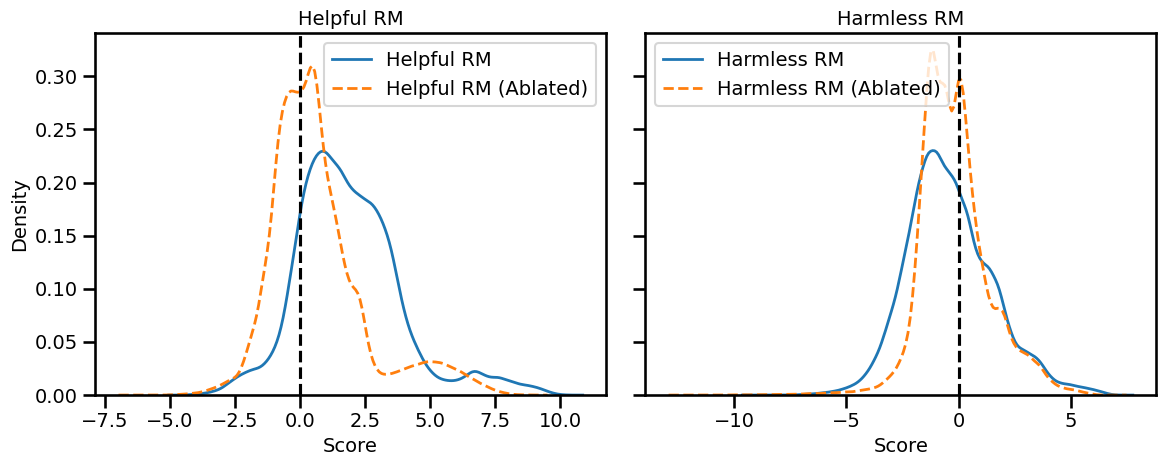

In [107]:
he_pref = []
he_aba_pref = []
ha_pref = []
ha_aba_pref = []

he_rej = []
he_aba_rej = []
ha_rej = []
ha_aba_rej = []

for model_name in MODEL_NAMES:
    for bench_dataset in BENCH_DATASETS:
        for seed in SEEDS:

            he_path = f'./save/results/{model_name}_helpful_{seed}/{bench_dataset}.json'
            ha_path = f'./save/results/{model_name}_harmless_{seed}/{bench_dataset}.json'
            he_aba_path = f'./save/results/{model_name}_helpful_{seed}/{bench_dataset}_ab=top_activations_absolute_per=10.json'
            ha_aba_path = f'./save/results/{model_name}_harmless_{seed}/{bench_dataset}_ab=top_activations_absolute_per=10.json'

            with open(he_path) as f:
                he = json.load(f)
            with open(ha_path) as f:
                ha = json.load(f)
            with open(he_aba_path) as f:
                he_aba = json.load(f)
            with open(ha_aba_path) as f:
                ha_aba = json.load(f)

            he_scores = np.array(he['score_pref'])
            ha_scores = np.array(ha['score_pref'])
            he_aba_scores = np.array(he_aba['score_pref'])
            ha_aba_scores = np.array(ha_aba['score_pref'])

            # preferred (col 0)
            he_pref.extend(he_scores[:, 0])
            he_aba_pref.extend(he_aba_scores[:, 0])
            ha_pref.extend(ha_scores[:, 0])
            ha_aba_pref.extend(ha_aba_scores[:, 0])

            # rejected (col 1)
            he_rej.extend(he_scores[:, 1])
            he_aba_rej.extend(he_aba_scores[:, 1])
            ha_rej.extend(ha_scores[:, 1])
            ha_aba_rej.extend(ha_aba_scores[:, 1])
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# ---- Helpful RM (combine pref + rej) ----
he_all = he_pref + he_rej
he_aba_all = he_aba_pref + he_aba_rej

sns.kdeplot(he_all, label="Helpful RM", linewidth=2, ax=axes[0])
sns.kdeplot(he_aba_all, label="Helpful RM (Ablated)", linewidth=2, linestyle="--", ax=axes[0])

axes[0].set_title("Helpful RM")
axes[0].axvline(0, linestyle="--", color="black")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Density")
axes[0].legend()

# ---- Harmless RM (combine pref + rej) ----
ha_all = ha_pref + ha_rej
ha_aba_all = ha_aba_pref + ha_aba_rej

sns.kdeplot(ha_all, label="Harmless RM", linewidth=2, ax=axes[1])
sns.kdeplot(ha_aba_all, label="Harmless RM (Ablated)", linewidth=2, linestyle="--", ax=axes[1])

axes[1].set_title("Harmless RM")
axes[1].axvline(0, linestyle="--", color="black")
axes[1].set_xlabel("Score")
axes[1].legend()

plt.tight_layout()
plt.savefig('save/fig/scoring_change_abalated.pdf')
plt.show()


In [73]:
ABALATION_TYPE2

['only_top_helpful_activations_absolute',
 'only_top_harmless_activations_absolute',
 'both_top_helpful_harmless_activations_absolute']

In [75]:
from collections import defaultdict
import numpy as np
import json
import pandas as pd

df_model_name = []
df_sub_task = []
df_dataset_name = []
df_variance = []
df_transferability = []
for abalation_type in ['']+ABALATION_TYPE2:
    if abalation_type=='':
        print('None abalated')
    else:
        print(abalation_type)
    for model_name in MODEL_NAMES:
        for bench_dataset in BENCH_DATASETS:

            transferability_dict = defaultdict(list)

            for seed in SEEDS:
                he_path = f'./save/results/{model_name}_helpful_{seed}/{bench_dataset}.json'
                ha_path = f'./save/results/{model_name}_harmless_{seed}/{bench_dataset}.json'
                if abalation_type!='':
                    hh_path = f'./save/results/{model_name}_helpful-harmless_{seed}/{bench_dataset}_ab={abalation_type}_per=10.json'
                else:
                    hh_path = f'./save/results/{model_name}_helpful-harmless_{seed}/{bench_dataset}.json'

                with open(he_path) as f:
                    he_results = json.load(f)['results']
                with open(ha_path) as f:
                    ha_results = json.load(f)['results']
                with open(hh_path) as f:
                    hh_results = json.load(f)['results']

                sub_set = subsub_set[bench_dataset]

                he_idx = defaultdict(list)
                ha_idx = defaultdict(list)
                hh_idx = defaultdict(list)

                for he, ha, hh, idx in zip(he_results, ha_results, hh_results, sub_set):
                    he_idx[idx].append(he)
                    ha_idx[idx].append(ha)
                    hh_idx[idx].append(hh)

                for key in hh_idx.keys():
                    intersection = 0
                    union = 0

                    for i in range(len(hh_idx[key])):

                        # HH correct AND (Helpful OR Harmless correct)
                        if (
                            hh_idx[key][i] == 1 and
                            (he_idx[key][i] == 1 or ha_idx[key][i] == 1)
                        ):
                            intersection += 1

                        # Helpful OR Harmless correct
                        if he_idx[key][i] == 1 or ha_idx[key][i] == 1:
                            union += 1

                    transferability = intersection / union if union > 0 else 0.0
                    transferability_dict[key].append(transferability)

            for key, values in transferability_dict.items():
                if key.lower() in SUB_TASK_2_AVOIDE:
                    continue

                df_model_name.append(model_name)
                df_sub_task.append(key)
                df_dataset_name.append(bench_dataset)
                df_variance.append(float(np.std(values)))
                df_transferability.append(float(np.mean(values)))

    df = pd.DataFrame({
        'model_name': df_model_name,
        'sub_task': df_sub_task,
        'dataset_name': df_dataset_name,
        'variance': df_variance,
        'transferance': df_transferability
    })

    df['sub_task'] = df['sub_task'].replace(NORMALISED_SUB_TYPE)

    print(df.groupby(['sub_task'])['transferance'].mean())
            # .to_dict(orient='index')

None abalated
sub_task
Alpaca Eval (Easy)          0.932693
Alpaca Eval (Hard)          0.959425
Alpaca Eval (Length)        0.817976
Chat                        0.560801
Do Not Answer               0.338166
Factuality                  0.407699
Focus                       0.248800
LLM Bar (Adver GPTInst)     0.269533
LLM Bar (Adver GPTOut)      0.472355
LLM Bar (Adver Manual)      0.242718
LLM Bar (Adver Neighbor)    0.241600
LLM Bar (Natural)           0.642603
MT Bench (Easy)             0.782687
MT Bench (Hard)             0.677590
MT Bench (Med)              0.672455
Math                        0.533225
Math PRM                    0.771764
Precise IF                  0.380896
Refusals Dangerous          0.444239
Refusals Offensive          0.884818
Safety                      0.411366
Safety Refuse               0.852205
Safety Response             0.564224
XStest Should Refuse        0.876228
XStest Should Respond       0.658131
Name: transferance, dtype: float64
only_top_helpful_

In [ ]:
df_model_name = []
df_sub_task = []
df_dataset_name = []
df_variance = []
df_transferability = []

for model_name in MODEL_NAMES:
    for bench_dataset in BENCH_DATASETS:

        transferability_dict = defaultdict(list)

        for seed in SEEDS:
            he_path = f'./save/results/{model_name}_helpful_{seed}/{bench_dataset}.json'
            ha_path = f'./save/results/{model_name}_harmless_{seed}/{bench_dataset}.json'
            hh_path = f'./save/results/{model_name}_helpful-harmless_{seed}/{bench_dataset}.json'

            with open(he_path) as f:
                he_results = json.load(f)['results']
            with open(ha_path) as f:
                ha_results = json.load(f)['results']
            with open(hh_path) as f:
                hh_results = json.load(f)['results']

            sub_set = subsub_set[bench_dataset]

            he_idx = defaultdict(list)
            ha_idx = defaultdict(list)
            hh_idx = defaultdict(list)

            for he, ha, hh, idx in zip(he_results, ha_results, hh_results, sub_set):
                he_idx[idx].append(he)
                ha_idx[idx].append(ha)
                hh_idx[idx].append(hh)

            for key in hh_idx.keys():
                intersection = 0
                union = 0

                for i in range(len(hh_idx[key])):

                    # HH correct AND (Helpful OR Harmless correct)
                    if (
                        hh_idx[key][i] == 1 and
                        (he_idx[key][i] == 1 or ha_idx[key][i] == 1)
                    ):
                        intersection += 1

                    # Helpful OR Harmless correct
                    if he_idx[key][i] == 1 or ha_idx[key][i] == 1:
                        union += 1

                transferability = intersection / union if union > 0 else 0.0
                transferability_dict[key].append(transferability)

        for key, values in transferability_dict.items():
            if key.lower() in SUB_TASK_2_AVOIDE:
                continue

            df_model_name.append(model_name)
            df_sub_task.append(key)
            df_dataset_name.append(bench_dataset)
            df_variance.append(float(np.std(values)))
            df_transferability.append(float(np.mean(values)))

df = pd.DataFrame({
    'model_name': df_model_name,
    'sub_task': df_sub_task,
    'dataset_name': df_dataset_name,
    'variance': df_variance,
    'transferance': df_transferability
})

df['sub_task'] = df['sub_task'].replace(NORMALISED_SUB_TYPE)

df.groupby(['sub_task'])['transferance'].mean()
        # .to_dict(orient='index')